In [5]:
import os
# 定义输出文件名
output_file = "mergedPositiveRawData.fna"
# 定义目标文件夹路径（相对当前脚本的路径）
target_dir = "./positiveRawData"
# 检查目标文件夹是否存在，避免报错
if not os.path.exists(target_dir):
    print(f"错误：找不到文件夹 {os.path.abspath(target_dir)}，请检查路径是否正确！")
else:
    # 获取目标文件夹下所有 .fna 文件并排序
    fna_files = sorted([f for f in os.listdir(target_dir) if f.endswith(".fna")])
    if not fna_files: print(f"警告：{target_dir} 文件夹中没有找到 .fna 文件！")
    else:
        # 合并文件（关键：拼接完整文件路径）
        with open(output_file, "w", encoding="utf-8") as outfile:
            for filename in fna_files:
                # 核心修复点：拼接文件夹和文件名，得到完整路径
                file_path = os.path.join(target_dir, filename)
                with open(file_path, "r", encoding="utf-8") as infile:
                    outfile.write(infile.read())
        print(f"合并完成！共合并 {len(fna_files)} 个 .fna 文件")
        print(f"输出文件路径：{os.path.abspath(output_file)}")

合并完成！共合并 7 个 .fna 文件
输出文件路径：c:\Users\Hanarei\Downloads\RNAProj\mergedPositiveRawData.fna


In [2]:
from Bio import SeqIO

# 读取正样本名称（避免负样本和正样本重复）
positiveRecords = list(SeqIO.parse("mergedPositiveRawData.fna", "fasta"))
positiveNames = [record.id.strip() for record in positiveRecords]  # 提取正样本lncRNA名称

# 读取GENCODE的负样本源文件，筛选符合条件的序列
negativeFilteredRecords = []
# 分批读取，避免内存溢出（适配小内存）
for record in SeqIO.parse("gencode.v49.lncRNA_transcripts_copy.fa", "fasta"):
    # 条件1：长度500-2000nt
    if 500 <= len(record.seq) <= 2000:
        # 条件2：名称不在正样本列表里
        if record.id not in positiveNames:
            negativeFilteredRecords.append(record)
    # 只挑100-150条，够用来建模就行，避免文件太大
    if len(negativeFilteredRecords) >= 150:
        break

# 保存筛选后的负样本
SeqIO.write(negativeFilteredRecords, "negative_filtered.fasta", "fasta")
print(f"筛选出 {len(negativeFilteredRecords)} 条负样本序列")

筛选出 150 条负样本序列


In [3]:
from Bio import SeqIO

# 读取正、负样本
positiveRawRecords = list(SeqIO.parse("positiveRawData.fna", "fasta"))
negativeFilteredRecords = list(SeqIO.parse("negativeFiltered.fasta", "fasta"))

# 1. 格式统一：大写、U替换为T（RNA转DNA格式，建模更通用）
for record in positiveRawRecords + negativeFilteredRecords:
    record.seq = record.seq.upper().replace("U", "T")
    record.description = ""  # 清空冗余描述，减小文件体积

# 2. 简单质控：去掉含N过多（>10%）、长度异常的序列
def cleanSequenceRecords(records):
    cleanedRecords = []
    for record in records:
        # 去掉N占比>10%的
        nitrogenBaseRatio = record.seq.count("N") / len(record.seq) if len(record.seq) > 0 else 1
        if nitrogenBaseRatio <= 0.1:
            # 再次确认长度（避免漏筛）
            if 500 <= len(record.seq) <= 2000:
                cleanedRecords.append(record)
    return cleanedRecords

positiveCleanedRecords = cleanSequenceRecords(positiveRawRecords)
negativeCleanedRecords = cleanSequenceRecords(negativeFilteredRecords)

# 3. 去重（按名称去重，简单高效）
positiveCleanedNames = []
positiveFinalRecords = []
for record in positiveCleanedRecords:
    if record.id not in positiveCleanedNames:
        positiveCleanedNames.append(record.id)
        positiveFinalRecords.append(record)

negativeCleanedNames = []
negativeFinalRecords = []
for record in negativeCleanedRecords:
    if record.id not in negativeCleanedNames:
        negativeCleanedNames.append(record.id)
        negativeFinalRecords.append(record)

# 保存质控后的文件
SeqIO.write(positiveFinalRecords, "positiveFinal.fasta", "fasta")
SeqIO.write(negativeFinalRecords, "negativeFinal.fasta", "fasta")

print(f"正样本最终保留：{len(positiveFinalRecords)} 条")
print(f"负样本最终保留：{len(negativeFinalRecords)} 条")

正样本最终保留：47 条
负样本最终保留：150 条


In [26]:
from Bio import SeqIO
from sklearn.model_selection import train_test_split

# 读取最终的正、负样本
positiveFinalRecords = list(SeqIO.parse("positiveFinal.fasta", "fasta"))
negativeFinalRecords = list(SeqIO.parse("negativeFinal.fasta", "fasta"))

# 划分函数：按7:1:1拆分（训练集70%、验证集10%、测试集10%）
def splitSequenceRecords(records):
    # 先分训练集（80%）和临时集（20%），固定随机种子保证可复现
    trainingSet, temporarySet = train_test_split(records, test_size=0.2, random_state=42)
    # 临时集再拆分为验证集和测试集（各10%）
    validationSet, testSet = train_test_split(temporarySet, test_size=0.5, random_state=42)
    return trainingSet, validationSet, testSet

# 拆分正、负样本
positiveTrainingSet, positiveValidationSet, positiveTestSet = splitSequenceRecords(positiveFinalRecords)
negativeTrainingSet, negativeValidationSet, negativeTestSet = splitSequenceRecords(negativeFinalRecords)

# 保存6个文件（直接用于后续建模）
SeqIO.write(positiveTrainingSet, "trainPositive.fasta", "fasta")
SeqIO.write(positiveValidationSet, "valPositive.fasta", "fasta")
SeqIO.write(positiveTestSet, "testPositive.fasta", "fasta")
SeqIO.write(negativeTrainingSet, "trainNegative.fasta", "fasta")
SeqIO.write(negativeValidationSet, "valNegative.fasta", "fasta")
SeqIO.write(negativeTestSet, "testNegative.fasta", "fasta")

print("数据集划分完成，生成以下文件：")
print(f"训练集正样本：{len(positiveTrainingSet)} 条\n训练集负样本：{len(negativeTrainingSet)} 条")
print(f"验证集正样本：{len(positiveValidationSet)} 条\n验证集负样本：{len(negativeValidationSet)} 条")
print(f"测试集正样本：{len(positiveTestSet)} 条\n测试集负样本：{len(negativeTestSet)} 条")

数据集划分完成，生成以下文件：
训练集正样本：37 条
训练集负样本：120 条
验证集正样本：5 条
验证集负样本：15 条
测试集正样本：5 条
测试集负样本：15 条


### ExtractSequenceFeatures.py

In [27]:
import pandas as pd
import numpy as np
from Bio import SeqIO
import math

# ===================== 核心工具函数：SEG算法实现（无第三方依赖） =====================
def GetNucleotideComplexityDictionary():
    NucleotideComplexityDictionary = {
        "A": 1.0, "T": 1.0, "C": 1.0, "G": 1.0,
        "N": 0.0, "R": 0.8, "Y": 0.8, "S": 0.8,
        "W": 0.8, "K": 0.8, "M": 0.8, "B": 0.6,
        "D": 0.6, "H": 0.6, "V": 0.6, "-": 0.0
    }
    return NucleotideComplexityDictionary

def CalculateSlidingWindowComplexity(SequenceString, WindowSize, StepSize, ComplexityDictionary):
    SequenceLength = len(SequenceString)
    WindowComplexityList = []
    WindowStartPositionList = []
    
    for StartPosition in range(0, SequenceLength - WindowSize + 1, StepSize):
        EndPosition = StartPosition + WindowSize
        WindowSequence = SequenceString[StartPosition:EndPosition]
        
        TotalComplexity = 0.0
        ValidResidueCount = 0
        for Residue in WindowSequence:
            if Residue in ComplexityDictionary:
                TotalComplexity += ComplexityDictionary[Residue]
                ValidResidueCount += 1
        
        if ValidResidueCount == 0:
            WindowComplexity = 0.0
        else:
            WindowComplexity = TotalComplexity / ValidResidueCount
        
        WindowComplexityList.append(WindowComplexity)
        WindowStartPositionList.append(StartPosition)
    
    return WindowComplexityList, WindowStartPositionList

def IdentifyLowComplexityRegionsBySegAlgorithm(SequenceString, WindowSize=12, Threshold=2.2, StepSize=1):
    if len(SequenceString) == 0:
        return 0.0, 0.0
    
    StandardBases = ["A", "T", "C", "G", "N", "R", "Y", "S", "W", "K", "M", "B", "D", "H", "V", "-"]
    CleanSequenceString = ""
    for Base in SequenceString.upper():
        if Base in StandardBases:
            CleanSequenceString += Base
    
    CleanSequenceLength = len(CleanSequenceString)
    if CleanSequenceLength < WindowSize:
        return 0.0, 0.0
    
    ComplexityDictionary = GetNucleotideComplexityDictionary()
    WindowComplexityList, WindowStartPositionList = CalculateSlidingWindowComplexity(
        CleanSequenceString, WindowSize, StepSize, ComplexityDictionary
    )
    
    LowComplexityWindowList = []
    for Index, Complexity in enumerate(WindowComplexityList):
        if Complexity < Threshold:
            StartPosition = WindowStartPositionList[Index]
            EndPosition = StartPosition + WindowSize
            LowComplexityWindowList.append((StartPosition, EndPosition))
    
    if not LowComplexityWindowList:
        return 0.0, 0.0
    
    MergedRegions = [list(LowComplexityWindowList[0])]
    for CurrentStart, CurrentEnd in LowComplexityWindowList[1:]:
        LastStart, LastEnd = MergedRegions[-1]
        if CurrentStart <= LastEnd:
            MergedRegions[-1][1] = max(LastEnd, CurrentEnd)
        else:
            MergedRegions.append([CurrentStart, CurrentEnd])
    
    TotalLowComplexityLength = sum([End - Start for Start, End in MergedRegions])
    LowComplexityRatio = round(TotalLowComplexityLength / CleanSequenceLength, 4)
    
    return TotalLowComplexityLength, LowComplexityRatio

# ===================== 特征提取核心函数（标准驼峰+全拼） =====================
def ExtractSequenceFeaturesFromFastaRecord(FastaSequenceRecord):
    SequenceString = str(FastaSequenceRecord.seq)
    SequenceLength = len(SequenceString)
    
    if SequenceLength == 0:
        return None
    
    AdenineCount = SequenceString.count("A")
    ThymineCount = SequenceString.count("T")
    CytosineCount = SequenceString.count("C")
    GuanineCount = SequenceString.count("G")
    
    AdenineRatio = round(AdenineCount / SequenceLength, 4)
    ThymineRatio = round(ThymineCount / SequenceLength, 4)
    CytosineRatio = round(CytosineCount / SequenceLength, 4)
    GuanineRatio = round(GuanineCount / SequenceLength, 4)
    
    GuanineCytosineContent = round((GuanineCount + CytosineCount) / SequenceLength, 4)
    
    _, LowComplexityRegionRatio = IdentifyLowComplexityRegionsBySegAlgorithm(SequenceString)
    
    DinucleotideCombinationList = [
        "AA", "AT", "AC", "AG",
        "TA", "TT", "TC", "TG",
        "CA", "CT", "CC", "CG",
        "GA", "GT", "GC", "GG"
    ]
    DinucleotideFrequencyList = []
    for DinucleotideCombination in DinucleotideCombinationList:
        DinucleotideCount = SequenceString.count(DinucleotideCombination)
        DinucleotideFrequency = round(DinucleotideCount / (SequenceLength - 1) if SequenceLength > 1 else 0.0, 4)
        DinucleotideFrequencyList.append(DinucleotideFrequency)
    
    FeatureList = [
        FastaSequenceRecord.id,
        AdenineRatio, ThymineRatio, CytosineRatio, GuanineRatio,
        GuanineCytosineContent,
        LowComplexityRegionRatio
    ] + DinucleotideFrequencyList
    
    return FeatureList

def ProcessLongNonCodingRnaDataset(PositiveSampleFastaFilePath, NegativeSampleFastaFilePath, PositiveLabel=1, NegativeLabel=0):
    PositiveSampleRecordList = list(SeqIO.parse(PositiveSampleFastaFilePath, "fasta"))
    PositiveSampleFeatureList = [
        ExtractSequenceFeaturesFromFastaRecord(Record)
        for Record in PositiveSampleRecordList
        if ExtractSequenceFeaturesFromFastaRecord(Record) is not None
    ]
    
    NegativeSampleRecordList = list(SeqIO.parse(NegativeSampleFastaFilePath, "fasta"))
    NegativeSampleFeatureList = [
        ExtractSequenceFeaturesFromFastaRecord(Record)
        for Record in NegativeSampleRecordList
        if ExtractSequenceFeaturesFromFastaRecord(Record) is not None
    ]
    
    FeatureColumnNameList = [
        "LongNonCodingRnaIdentifier",
        "AdenineRatio", "ThymineRatio", "CytosineRatio", "GuanineRatio",
        "GuanineCytosineContent", "LowComplexityRegionRatio"
    ] + [f"Dinucleotide{Combination}" for Combination in [
        "AA", "AT", "AC", "AG",
        "TA", "TT", "TC", "TG",
        "CA", "CT", "CC", "CG",
        "GA", "GT", "GC", "GG"
    ]]
    
    PositiveSampleDataFrame = pd.DataFrame(PositiveSampleFeatureList, columns=FeatureColumnNameList)
    PositiveSampleDataFrame["SampleLabel"] = PositiveLabel
    
    NegativeSampleDataFrame = pd.DataFrame(NegativeSampleFeatureList, columns=FeatureColumnNameList)
    NegativeSampleDataFrame["SampleLabel"] = NegativeLabel
    
    CombinedDatasetDataFrame = pd.concat(
        [PositiveSampleDataFrame, NegativeSampleDataFrame],
        ignore_index=True,
        axis=0
    )
    
    return CombinedDatasetDataFrame

# ===================== 主程序入口（适配你当前的文件名） =====================
if __name__ == "__main__":
    # 直接使用你文件夹里的真实文件名
    TrainingSetPositiveFilePath = "trainPositive.fasta"
    TrainingSetNegativeFilePath = "trainNegative.fasta"
    ValidationSetPositiveFilePath = "valPositive.fasta"
    ValidationSetNegativeFilePath = "valNegative.fasta"
    TestSetPositiveFilePath = "testPositive.fasta"
    TestSetNegativeFilePath = "testNegative.fasta"
    
    try:
        TrainingSetDataFrame = ProcessLongNonCodingRnaDataset(TrainingSetPositiveFilePath, TrainingSetNegativeFilePath)
        ValidationSetDataFrame = ProcessLongNonCodingRnaDataset(ValidationSetPositiveFilePath, ValidationSetNegativeFilePath)
        TestSetDataFrame = ProcessLongNonCodingRnaDataset(TestSetPositiveFilePath, TestSetNegativeFilePath)
        
        TrainingSetDataFrame.to_csv("TrainingSetSequenceFeatures.csv", index=False)
        ValidationSetDataFrame.to_csv("ValidationSetSequenceFeatures.csv", index=False)
        TestSetDataFrame.to_csv("TestSetSequenceFeatures.csv", index=False)
        
        print("=== lncRNA序列特征提取完成（SEG算法） ===")
        print(f"训练集 - 样本数量：{TrainingSetDataFrame.shape[0]}\n特征数量：{TrainingSetDataFrame.shape[1]}")
        print(f"验证集 - 样本数量：{ValidationSetDataFrame.shape[0]}\n特征数量：{ValidationSetDataFrame.shape[1]}")
        print(f"测试集 - 样本数量：{TestSetDataFrame.shape[0]}\n特征数量：{TestSetDataFrame.shape[1]}")
        print("\n前5条训练集特征示例：")
        print(TrainingSetDataFrame.head())
    
    except FileNotFoundError as FileError:
        print(f"错误：找不到指定的FASTA文件 - {FileError.filename}")
        print("请检查文件路径是否正确，或文件名是否匹配")
    except Exception as GeneralError:
        print(f"错误：特征提取过程中出现异常 - {str(GeneralError)}")
        print("请检查输入的FASTA文件格式是否符合标准")

=== lncRNA序列特征提取完成（SEG算法） ===
训练集 - 样本数量：157
特征数量：24
验证集 - 样本数量：20
特征数量：24
测试集 - 样本数量：20
特征数量：24

前5条训练集特征示例：
  LongNonCodingRnaIdentifier  AdenineRatio  ThymineRatio  CytosineRatio  \
0                NR_152529.2        0.2699        0.2662         0.2163   
1                NR_152523.2        0.2739        0.2639         0.2084   
2                NR_152526.2        0.2702        0.2735         0.2055   
3                NR_186289.1        0.2648        0.2494         0.2139   
4                NR_186281.1        0.2702        0.2668         0.2083   

   GuanineRatio  GuanineCytosineContent  LowComplexityRegionRatio  \
0        0.2477                  0.4640                       1.0   
1        0.2538                  0.4622                       1.0   
2        0.2508                  0.4563                       1.0   
3        0.2719                  0.4858                       1.0   
4        0.2547                  0.4630                       1.0   

   DinucleotideAA  Dinuc

### BuildRandomForestModel.py

=== 随机森林模型性能评估结果 ===
验证集准确率 (Accuracy)：1.0000
验证集曲线下面积 (AUC)：1.0000
测试集准确率 (Accuracy)：1.0000
测试集曲线下面积 (AUC)：1.0000

=== 测试集分类详细报告 ===
                 precision    recall  f1-score   support

Negative Sample       1.00      1.00      1.00        15
Positive Sample       1.00      1.00      1.00         5

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20


=== 特征重要性排名（前10） ===
               FeatureName  ImportanceValue
0             AdenineRatio         0.170389
2            CytosineRatio         0.160314
4   GuanineCytosineContent         0.122176
10          DinucleotideTA         0.115547
6           DinucleotideAA         0.101132
7           DinucleotideAT         0.099718
16          DinucleotideCC         0.092913
20          DinucleotideGC         0.058097
19          DinucleotideGT         0.027247
14          DinucleotideCA         0.018551

模型已保存为：LongNon

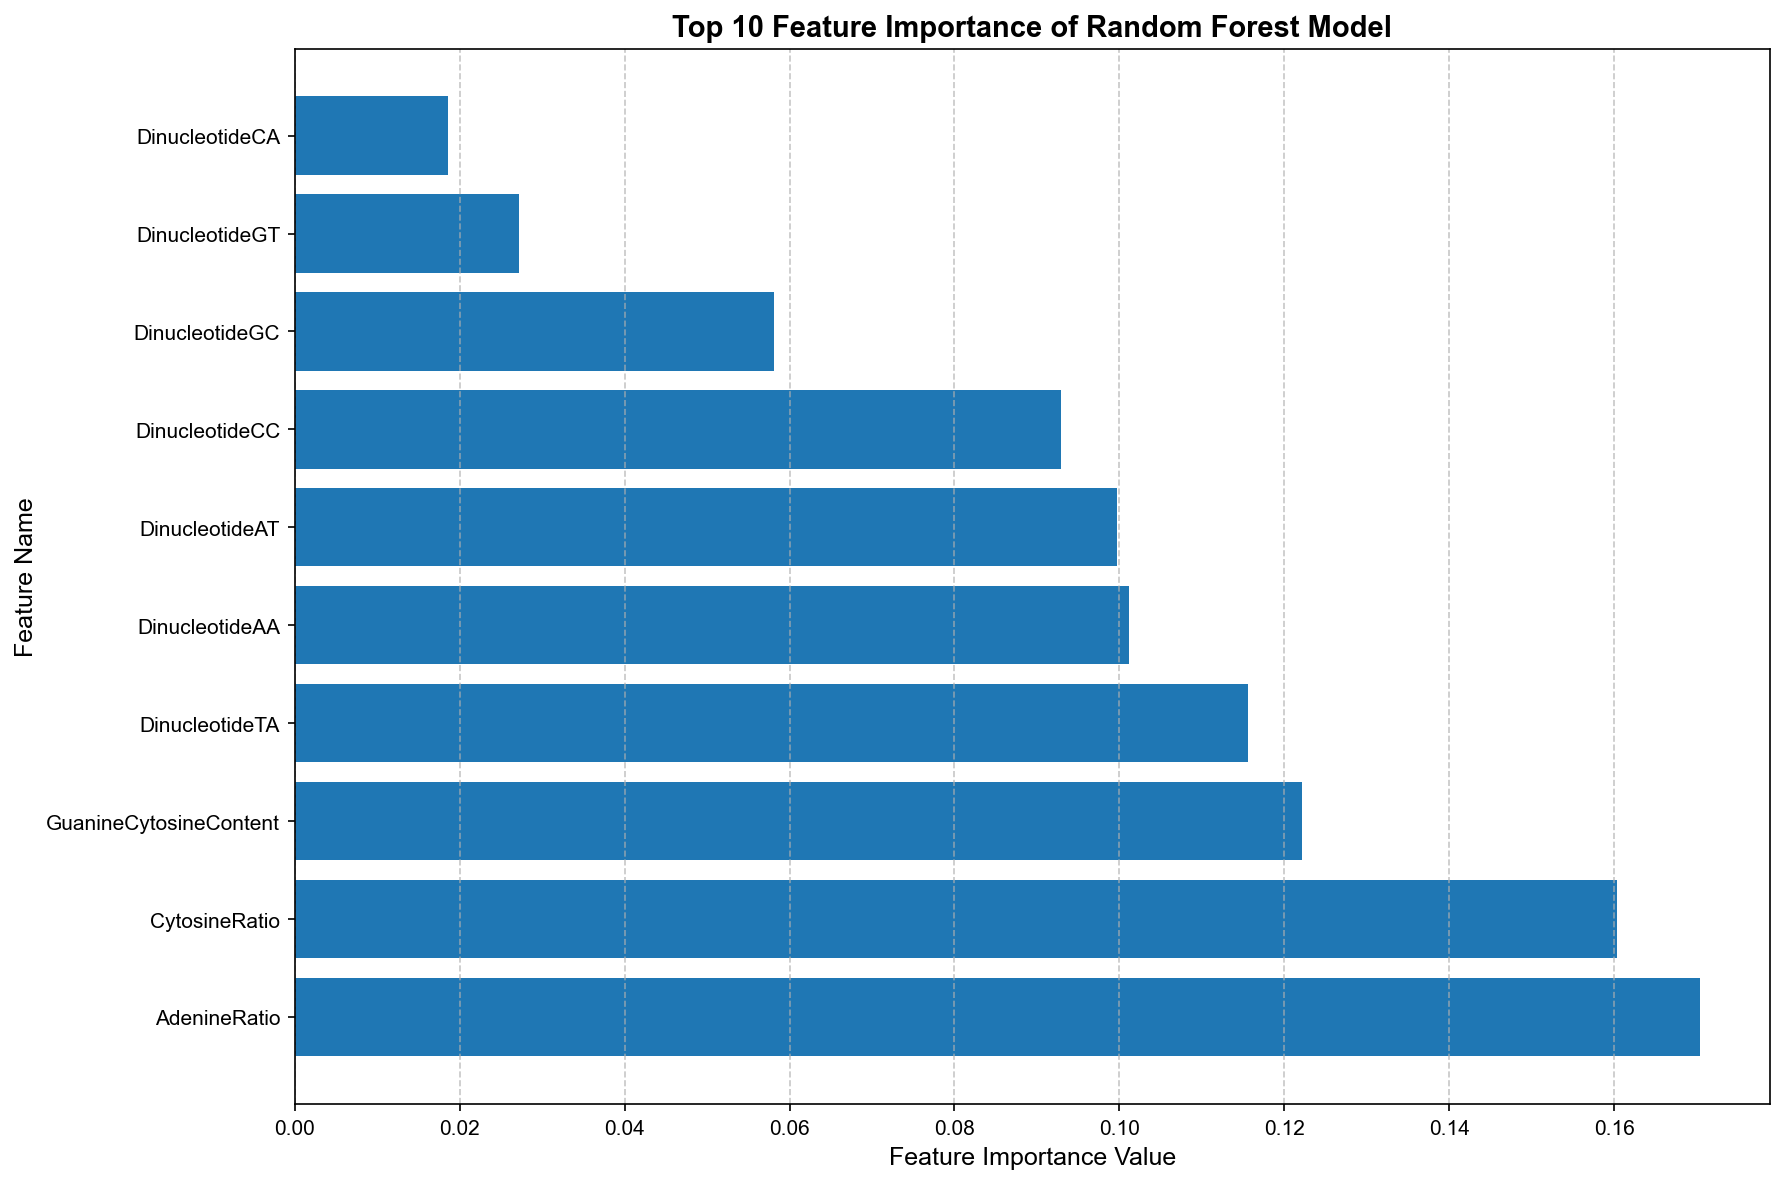

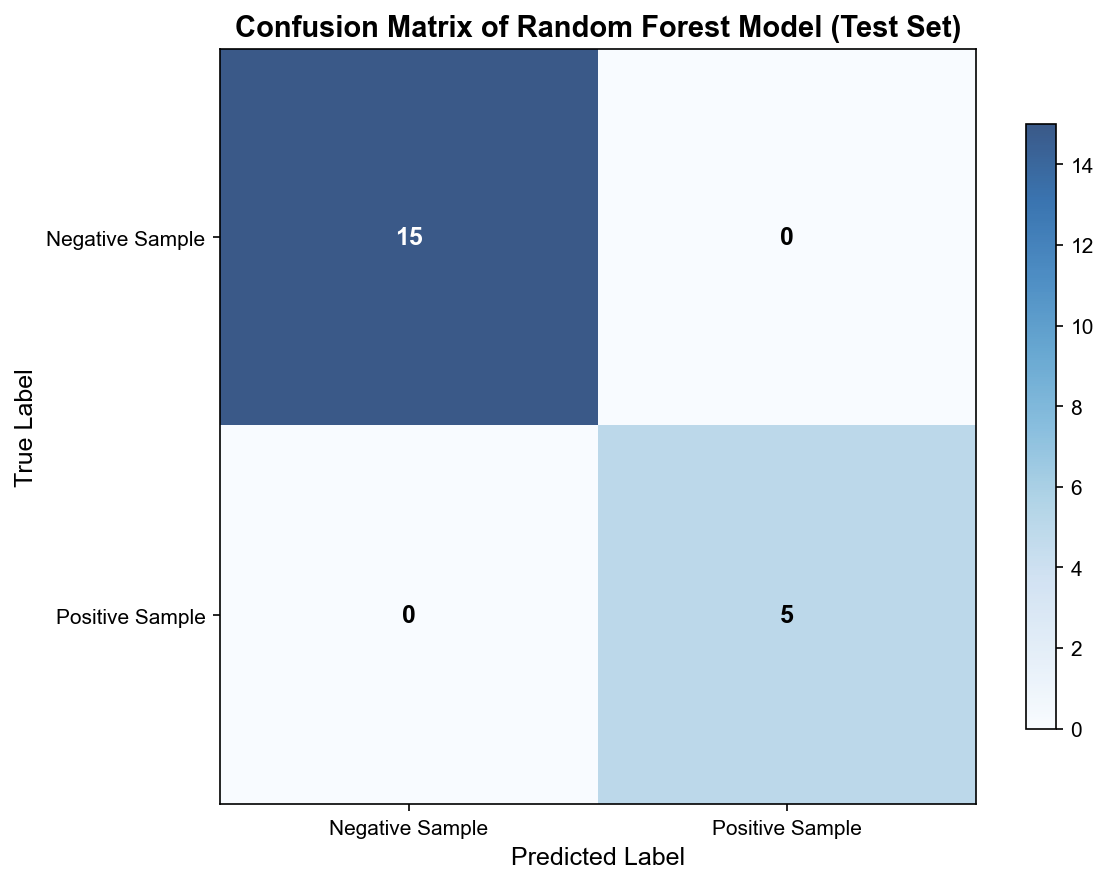

In [28]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import joblib

# 1. 读取特征数据（分离特征和标签，适配新列名）
def LoadLongNonCodingRnaDataset(CsvFilePath):
    """
    加载lncRNA特征数据集（分离特征和标签）
    参数：
        CsvFilePath: 特征矩阵CSV文件路径
    返回：
        FeatureMatrix: 特征矩阵（DataFrame）
        LabelVector: 标签向量（Series）
    """
    DataFrame = pd.read_csv(CsvFilePath)
    # 列名已更新为：LongNonCodingRnaIdentifier（替代LongNonCodingRnaName）、SampleLabel（替代Label）
    FeatureMatrix = DataFrame.drop(["LongNonCodingRnaIdentifier", "SampleLabel"], axis=1)  
    LabelVector = DataFrame["SampleLabel"]  
    return FeatureMatrix, LabelVector

# 加载训练/验证/测试集（适配特征提取生成的CSV文件名）
TrainingFeatureMatrix, TrainingLabelVector = LoadLongNonCodingRnaDataset("TrainingSetSequenceFeatures.csv")
ValidationFeatureMatrix, ValidationLabelVector = LoadLongNonCodingRnaDataset("ValidationSetSequenceFeatures.csv")
TestFeatureMatrix, TestLabelVector = LoadLongNonCodingRnaDataset("TestSetSequenceFeatures.csv")

# 2. 构建随机森林模型（轻量级参数，适配小内存）
RandomForestModel = RandomForestClassifier(
    n_estimators=100,  # 树的数量，100足够满足毕设需求
    max_depth=10,      # 限制树深度，避免过拟合
    random_state=42,   # 固定随机种子，保证结果可复现
    n_jobs=1           # 单线程运行，减少内存占用
)

# 3. 训练模型
RandomForestModel.fit(TrainingFeatureMatrix, TrainingLabelVector)

# 4. 模型评估（核心指标，直接用于论文结果章节）
# 验证集评估
ValidationSetPrediction = RandomForestModel.predict(ValidationFeatureMatrix)
ValidationSetProbability = RandomForestModel.predict_proba(ValidationFeatureMatrix)[:, 1]
ValidationSetAccuracy = accuracy_score(ValidationLabelVector, ValidationSetPrediction)
ValidationSetAreaUnderCurve = roc_auc_score(ValidationLabelVector, ValidationSetProbability)

# 测试集评估（最终性能，论文核心结果）
TestSetPrediction = RandomForestModel.predict(TestFeatureMatrix)
TestSetProbability = RandomForestModel.predict_proba(TestFeatureMatrix)[:, 1]
TestSetAccuracy = accuracy_score(TestLabelVector, TestSetPrediction)
TestSetAreaUnderCurve = roc_auc_score(TestLabelVector, TestSetProbability)

# 输出评估结果（格式化，便于复制到论文）
print("=== 随机森林模型性能评估结果 ===")
print(f"验证集准确率 (Accuracy)：{ValidationSetAccuracy:.4f}")
print(f"验证集曲线下面积 (AUC)：{ValidationSetAreaUnderCurve:.4f}")
print(f"测试集准确率 (Accuracy)：{TestSetAccuracy:.4f}")
print(f"测试集曲线下面积 (AUC)：{TestSetAreaUnderCurve:.4f}")

print("\n=== 测试集分类详细报告 ===")
print(classification_report(TestLabelVector, TestSetPrediction, target_names=["Negative Sample", "Positive Sample"]))

# 5. 特征重要性分析（论文关键图表素材）
FeatureImportanceDataFrame = pd.DataFrame({
    "FeatureName": TrainingFeatureMatrix.columns,
    "ImportanceValue": RandomForestModel.feature_importances_
}).sort_values("ImportanceValue", ascending=False)

print("\n=== 特征重要性排名（前10） ===")
print(FeatureImportanceDataFrame.head(10))

# 6. 保存训练好的模型（便于后续预测候选lncRNA）
joblib.dump(RandomForestModel, "LongNonCodingRnaPhaseSeparationRandomForestModel.pkl")
print("\n模型已保存为：LongNonCodingRnaPhaseSeparationRandomForestModel.pkl")

# 7. 绘制特征重要性图（论文可用，标准化样式）
plt.rcParams["font.sans-serif"] = ["Arial", "SimHei"]  # 解决中文显示问题
plt.figure(figsize=(12, 8))
# 取前10个重要特征绘图
TopTenFeatureDataFrame = FeatureImportanceDataFrame.head(10)
plt.barh(TopTenFeatureDataFrame["FeatureName"], TopTenFeatureDataFrame["ImportanceValue"], color="#1f77b4")
plt.xlabel("Feature Importance Value", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.title("Top 10 Feature Importance of Random Forest Model", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("LongNonCodingRnaFeatureImportance.png", dpi=150, bbox_inches="tight")  # 适中分辨率，兼顾体积和清晰度
print("特征重要性图已保存为：LongNonCodingRnaFeatureImportance.png")

# 8. 绘制混淆矩阵（论文可用，标准化样式）
ConfusionMatrix = confusion_matrix(TestLabelVector, TestSetPrediction)
plt.figure(figsize=(8, 6))
plt.imshow(ConfusionMatrix, cmap="Blues", alpha=0.8)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix of Random Forest Model (Test Set)", fontsize=14, fontweight="bold")
plt.colorbar(shrink=0.8)
# 设置刻度标签
plt.xticks([0, 1], ["Negative Sample", "Positive Sample"], fontsize=10)
plt.yticks([0, 1], ["Negative Sample", "Positive Sample"], fontsize=10)
# 标注数值（保证可读性）
for i in range(2):
    for j in range(2):
        TextColor = "white" if ConfusionMatrix[i, j] > ConfusionMatrix.max()/2 else "black"
        plt.text(j, i, f"{ConfusionMatrix[i, j]}", ha="center", va="center", color=TextColor, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("LongNonCodingRnaConfusionMatrix.png", dpi=150, bbox_inches="tight")
print("混淆矩阵图已保存为：LongNonCodingRnaConfusionMatrix.png")

print("\n=== 随机森林模型训练完成 ===")
print("生成文件清单：")
print("1. LongNonCodingRnaPhaseSeparationRandomForestModel.pkl（训练好的模型）")
print("2. LongNonCodingRnaFeatureImportance.png（特征重要性图）")
print("3. LongNonCodingRnaConfusionMatrix.png（混淆矩阵图）")

### PredictCandidateLongNonCodingRna.py

In [29]:
import pandas as pd
import joblib
from Bio import SeqIO

# ===================== 复用特征提取核心函数（和之前保持一致） =====================
import math

def GetNucleotideComplexityDictionary():
    NucleotideComplexityDictionary = {
        "A": 1.0, "T": 1.0, "C": 1.0, "G": 1.0,
        "N": 0.0, "R": 0.8, "Y": 0.8, "S": 0.8,
        "W": 0.8, "K": 0.8, "M": 0.8, "B": 0.6,
        "D": 0.6, "H": 0.6, "V": 0.6, "-": 0.0
    }
    return NucleotideComplexityDictionary

def CalculateSlidingWindowComplexity(SequenceString, WindowSize, StepSize, ComplexityDictionary):
    SequenceLength = len(SequenceString)
    WindowComplexityList = []
    WindowStartPositionList = []
    
    for StartPosition in range(0, SequenceLength - WindowSize + 1, StepSize):
        EndPosition = StartPosition + WindowSize
        WindowSequence = SequenceString[StartPosition:EndPosition]
        
        TotalComplexity = 0.0
        ValidResidueCount = 0
        for Residue in WindowSequence:
            if Residue in ComplexityDictionary:
                TotalComplexity += ComplexityDictionary[Residue]
                ValidResidueCount += 1
        
        if ValidResidueCount == 0:
            WindowComplexity = 0.0
        else:
            WindowComplexity = TotalComplexity / ValidResidueCount
        
        WindowComplexityList.append(WindowComplexity)
        WindowStartPositionList.append(StartPosition)
    
    return WindowComplexityList, WindowStartPositionList

def IdentifyLowComplexityRegionsBySegAlgorithm(SequenceString, WindowSize=12, Threshold=2.2, StepSize=1):
    if len(SequenceString) == 0:
        return 0.0, 0.0
    
    StandardBases = ["A", "T", "C", "G", "N", "R", "Y", "S", "W", "K", "M", "B", "D", "H", "V", "-"]
    CleanSequenceString = ""
    for Base in SequenceString.upper():
        if Base in StandardBases:
            CleanSequenceString += Base
    
    CleanSequenceLength = len(CleanSequenceString)
    if CleanSequenceLength < WindowSize:
        return 0.0, 0.0
    
    ComplexityDictionary = GetNucleotideComplexityDictionary()
    WindowComplexityList, WindowStartPositionList = CalculateSlidingWindowComplexity(
        CleanSequenceString, WindowSize, StepSize, ComplexityDictionary
    )
    
    LowComplexityWindowList = []
    for Index, Complexity in enumerate(WindowComplexityList):
        if Complexity < Threshold:
            StartPosition = WindowStartPositionList[Index]
            EndPosition = StartPosition + WindowSize
            LowComplexityWindowList.append((StartPosition, EndPosition))
    
    if not LowComplexityWindowList:
        return 0.0, 0.0
    
    MergedRegions = [list(LowComplexityWindowList[0])]
    for CurrentStart, CurrentEnd in LowComplexityWindowList[1:]:
        LastStart, LastEnd = MergedRegions[-1]
        if CurrentStart <= LastEnd:
            MergedRegions[-1][1] = max(LastEnd, CurrentEnd)
        else:
            MergedRegions.append([CurrentStart, CurrentEnd])
    
    TotalLowComplexityLength = sum([End - Start for Start, End in MergedRegions])
    LowComplexityRatio = round(TotalLowComplexityLength / CleanSequenceLength, 4)
    
    return TotalLowComplexityLength, LowComplexityRatio

def ExtractSequenceFeaturesFromFastaRecord(FastaSequenceRecord):
    """
    从FASTA记录提取lncRNA序列特征（和训练集特征完全一致）
    """
    SequenceString = str(FastaSequenceRecord.seq)
    SequenceLength = len(SequenceString)
    
    if SequenceLength == 0:
        return None
    
    # 1. 单碱基组成占比
    AdenineCount = SequenceString.count("A")
    ThymineCount = SequenceString.count("T")
    CytosineCount = SequenceString.count("C")
    GuanineCount = SequenceString.count("G")
    
    AdenineRatio = round(AdenineCount / SequenceLength, 4)
    ThymineRatio = round(ThymineCount / SequenceLength, 4)
    CytosineRatio = round(CytosineCount / SequenceLength, 4)
    GuanineRatio = round(GuanineCount / SequenceLength, 4)
    
    # 2. GC含量（全拼列名）
    GuanineCytosineContent = round((GuanineCount + CytosineCount) / SequenceLength, 4)
    
    # 3. 低复杂度区域占比（SEG算法）
    _, LowComplexityRegionRatio = IdentifyLowComplexityRegionsBySegAlgorithm(SequenceString)
    
    # 4. 二核苷酸频率
    DinucleotideCombinationList = [
        "AA", "AT", "AC", "AG",
        "TA", "TT", "TC", "TG",
        "CA", "CT", "CC", "CG",
        "GA", "GT", "GC", "GG"
    ]
    DinucleotideFrequencyList = []
    for DinucleotideCombination in DinucleotideCombinationList:
        DinucleotideCount = SequenceString.count(DinucleotideCombination)
        DinucleotideFrequency = round(DinucleotideCount / (SequenceLength - 1) if SequenceLength > 1 else 0.0, 4)
        DinucleotideFrequencyList.append(DinucleotideFrequency)
    
    # 整合特征（列名和训练集完全一致）
    FeatureList = [
        FastaSequenceRecord.id,
        AdenineRatio, ThymineRatio, CytosineRatio, GuanineRatio,
        GuanineCytosineContent,
        LowComplexityRegionRatio
    ] + DinucleotideFrequencyList
    
    return FeatureList

# ===================== 候选lncRNA预测主逻辑 =====================
def PredictCandidateLongNonCodingRnaPhaseSeparation(CandidateFastaFilePath, TrainedModelFilePath, ConfidenceThreshold=0.8):
    """
    预测候选lncRNA的相分离潜力
    参数：
        CandidateFastaFilePath: 待预测lncRNA的FASTA文件路径
        TrainedModelFilePath: 训练好的随机森林模型路径
        ConfidenceThreshold: 高置信度阈值（默认0.8）
    返回：
        全量预测结果DataFrame、高置信度结果DataFrame
    """
    # 1. 加载训练好的模型（适配新的模型文件名）
    try:
        RandomForestModel = joblib.load(TrainedModelFilePath)
        print(f"成功加载模型：{TrainedModelFilePath}")
    except FileNotFoundError:
        print(f"错误：未找到模型文件 {TrainedModelFilePath}")
        print("请确认模型文件名和路径是否正确")
        return None, None
    
    # 2. 读取待预测的lncRNA序列
    try:
        CandidateSequenceRecords = list(SeqIO.parse(CandidateFastaFilePath, "fasta"))
        print(f"成功读取 {len(CandidateSequenceRecords)} 条候选lncRNA序列")
    except FileNotFoundError:
        print(f"错误：未找到FASTA文件 {CandidateFastaFilePath}")
        return None, None
    
    # 3. 提取特征（复用训练集的特征提取逻辑）
    CandidateSequenceFeatures = [
        ExtractSequenceFeaturesFromFastaRecord(Record) 
        for Record in CandidateSequenceRecords 
        if ExtractSequenceFeaturesFromFastaRecord(Record) is not None
    ]
    
    if len(CandidateSequenceFeatures) == 0:
        print("错误：未提取到有效特征，请检查FASTA文件格式")
        return None, None
    
    # 4. 定义特征列名（和训练集完全一致，全拼+驼峰）
    FeatureColumnNameList = [
        "LongNonCodingRnaIdentifier",
        "AdenineRatio", "ThymineRatio", "CytosineRatio", "GuanineRatio",
        "GuanineCytosineContent", "LowComplexityRegionRatio"
    ] + [f"Dinucleotide{Combination}" for Combination in [
        "AA", "AT", "AC", "AG",
        "TA", "TT", "TC", "TG",
        "CA", "CT", "CC", "CG",
        "GA", "GT", "GC", "GG"
    ]]
    
    # 5. 构建特征矩阵
    CandidateDataFrame = pd.DataFrame(CandidateSequenceFeatures, columns=FeatureColumnNameList)
    CandidateFeatureMatrix = CandidateDataFrame.drop("LongNonCodingRnaIdentifier", axis=1)
    
    # 6. 预测相分离潜力
    CandidateDataFrame["PredictionProbability"] = RandomForestModel.predict_proba(CandidateFeatureMatrix)[:, 1]
    CandidateDataFrame["PredictionLabel"] = RandomForestModel.predict(CandidateFeatureMatrix)
    
    # 7. 筛选高置信度候选
    HighConfidenceCandidateDataFrame = CandidateDataFrame[CandidateDataFrame["PredictionProbability"] >= ConfidenceThreshold]
    
    return CandidateDataFrame, HighConfidenceCandidateDataFrame

# ===================== 主程序入口 =====================
if __name__ == "__main__":
    # 配置文件路径（请根据实际文件修改）
    CandidateFastaFilePath = "gencode.v49.lncRNA_transcripts_copy.fa"  # 你的候选lncRNA文件
    TrainedModelFilePath = "LongNonCodingRnaPhaseSeparationRandomForestModel.pkl"  # 训练好的模型
    ConfidenceThreshold = 0.8  # 高置信度阈值
    
    # 执行预测
    CandidateDataFrame, HighConfidenceCandidateDataFrame = PredictCandidateLongNonCodingRnaPhaseSeparation(
        CandidateFastaFilePath, TrainedModelFilePath, ConfidenceThreshold
    )
    
    if CandidateDataFrame is not None and HighConfidenceCandidateDataFrame is not None:
        # 保存结果
        CandidateDataFrame.to_csv("AllCandidateLongNonCodingRnaPredictionResult.csv", index=False)
        HighConfidenceCandidateDataFrame.to_csv("HighConfidencePhaseSeparationLongNonCodingRna.csv", index=False)
        
        # 输出结果统计
        print("\n=== 候选lncRNA相分离潜力预测结果 ===")
        print(f"总预测lncRNA数量：{len(CandidateDataFrame)}")
        print(f"高置信度（≥{ConfidenceThreshold}）相分离lncRNA数量：{len(HighConfidenceCandidateDataFrame)}")
        print(f"高置信度占比：{len(HighConfidenceCandidateDataFrame)/len(CandidateDataFrame):.4f}")
        
        # 输出前10个高置信度候选
        print("\n前10个高置信度候选lncRNA（概率降序）：")
        TopTenHighConfidence = HighConfidenceCandidateDataFrame.sort_values("PredictionProbability", ascending=False).head(10)
        print(TopTenHighConfidence[["LongNonCodingRnaIdentifier", "PredictionProbability", "PredictionLabel"]])
        
        print("\n=== 结果文件已保存 ===")
        print("1. AllCandidateLongNonCodingRnaPredictionResult.csv（全量预测结果）")
        print("2. HighConfidencePhaseSeparationLongNonCodingRna.csv（高置信度候选）")

成功加载模型：LongNonCodingRnaPhaseSeparationRandomForestModel.pkl
成功读取 197211 条候选lncRNA序列

=== 候选lncRNA相分离潜力预测结果 ===
总预测lncRNA数量：197211
高置信度（≥0.8）相分离lncRNA数量：114297
高置信度占比：0.5796

前10个高置信度候选lncRNA（概率降序）：
                               LongNonCodingRnaIdentifier  \
130112  ENST00000670117.1|ENSG00000256193.7|OTTHUMG000...   
130122  ENST00000735939.1|ENSG00000256643.2|OTTHUMG000...   
72806   ENST00000792729.1|ENSG00000236700.9|OTTHUMG000...   
72805   ENST00000792732.1|ENSG00000236700.9|OTTHUMG000...   
72804   ENST00000792731.1|ENSG00000236700.9|OTTHUMG000...   
72803   ENST00000792733.1|ENSG00000236700.9|OTTHUMG000...   
197121  ENST00000795710.1|ENSG00000303573.1|-|-|ENST00...   
905     ENST00000743862.1|ENSG00000225880.7|OTTHUMG000...   
907     ENST00000743863.1|ENSG00000225880.7|OTTHUMG000...   
917     ENST00000473798.3|ENSG00000225880.7|OTTHUMG000...   

        PredictionProbability  PredictionLabel  
130112                    1.0                1  
130122                    1.0   

### AdvancedFeatureEngineering.py

成功加载数据集：TrainingSetSequenceFeatures.csv，共22个特征，157个样本
成功加载数据集：TestSetSequenceFeatures.csv，共22个特征，20个样本

特征标准化完成，已消除数值范围差异影响

=== RFE筛选过程验证 ===
RFE支持向量长度（原始特征数）：22
RFE筛选出的特征数量：10
是否符合n_features_to_select=10：True

=== RFE筛选的核心特征（前10个，已去重修复） ===
1. ThymineRatio
2. AdenineRatio
3. CytosineRatio
4. GuanineRatio
5. GuanineCytosineContent
6. LowComplexityRegionRatio
7. DinucleotideAA
8. DinucleotideAT
9. DinucleotideAC
10. DinucleotideAG

=== 选择的Top3核心特征（用于交互分析） ===
['GuanineCytosineContent', 'LowComplexityRegionRatio', 'ThymineRatio']

=== 新增的交互特征 ===
1. GuanineCytosineContentMultiplyLowComplexityRegionRatio（GuanineCytosineContent × LowComplexityRegionRatio）
2. GuanineCytosineContentMultiplyThymineRatio（GuanineCytosineContent × ThymineRatio）

=== PCA降维效果评估 ===
前10维主成分累计方差解释率：0.9985
各主成分方差解释率：
主成分1：0.6969
主成分2：0.2205
主成分3：0.0346
主成分4：0.0156
主成分5：0.0104
主成分6：0.0079
主成分7：0.0048
主成分8：0.0035
主成分9：0.0032
主成分10：0.0010

=== 特征工程效果对比（核心指标：AUC） ===
                FeatureType  TestSetAreaUnderCurve
0 

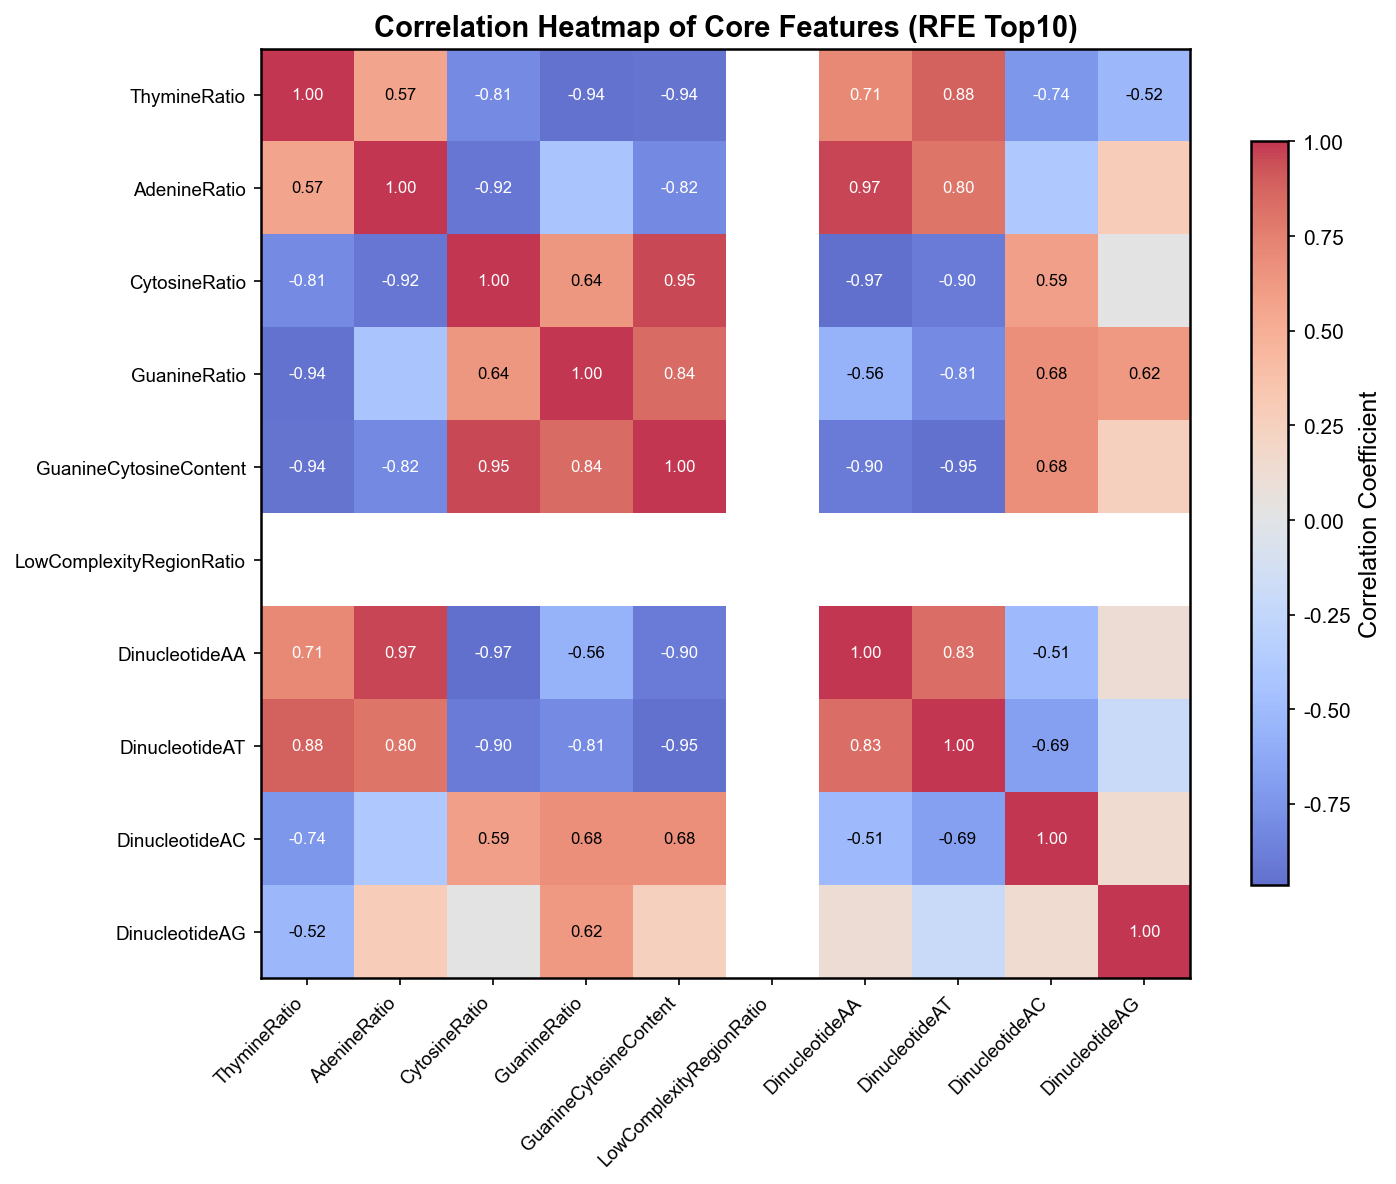

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler  # 新增：特征标准化（解决收敛慢问题）

# ===================== 全局字体配置（统一适配论文要求） =====================
# 英文Arial、中文黑体，标题Arial加粗，解决中文乱码和负号显示问题
plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'sans-serif'
# 统一图表样式（论文级标准）
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['figure.titlesize'] = 14

# 1. 加载原始特征数据（适配统一列名，解决KeyError）
def LoadFeatureDataset(CsvFilePath):
    """
    加载特征数据集（分离特征和标签，适配标准列名）
    参数：
        CsvFilePath: 特征矩阵CSV文件路径
    返回：
        FeatureMatrix: 特征矩阵
        LabelVector: 标签向量
        FeatureNames: 特征名称列表
    """
    try:
        DatasetDataFrame = pd.read_csv(CsvFilePath)
        # 替换为统一列名：LongNonCodingRnaIdentifier（替代LongNonCodingRnaName）、SampleLabel（替代Label）
        FeatureMatrix = DatasetDataFrame.drop(["LongNonCodingRnaIdentifier", "SampleLabel"], axis=1)
        LabelVector = DatasetDataFrame["SampleLabel"]
        FeatureNames = FeatureMatrix.columns.tolist()
        print(f"成功加载数据集：{CsvFilePath}，共{len(FeatureNames)}个特征，{len(FeatureMatrix)}个样本")
        
        # 新增：数据异常检测（避免计算卡顿/报错）
        null_count = FeatureMatrix.isnull().sum().sum()
        inf_count = np.isinf(FeatureMatrix).sum().sum()
        if null_count > 0:
            FeatureMatrix = FeatureMatrix.fillna(FeatureMatrix.mean())  # 缺失值用均值填充
            print(f"数据集存在{null_count}个缺失值，已用均值填充")
        if inf_count > 0:
            FeatureMatrix = FeatureMatrix.replace([np.inf, -np.inf], np.nan).fillna(FeatureMatrix.mean())
            print(f"数据集存在{inf_count}个无穷值，已替换为均值填充")
        
        # 新增：检测并修复重复列名（核心！解决特征重复的根源）
        duplicate_features = [feat for feat in FeatureNames if FeatureNames.count(feat) > 1]
        if duplicate_features:
            print(f"\n⚠️ 检测到重复特征列名：{list(set(duplicate_features))}，已自动重命名去重")
            # 重命名重复列（添加序号后缀）
            new_feature_names = []
            feat_count = {}
            for feat in FeatureNames:
                if feat in feat_count:
                    feat_count[feat] += 1
                    new_feature_names.append(f"{feat}_{feat_count[feat]}")
                else:
                    feat_count[feat] = 0
                    new_feature_names.append(feat)
            FeatureMatrix.columns = new_feature_names
            FeatureNames = new_feature_names
        
        return FeatureMatrix, LabelVector, FeatureNames
    except FileNotFoundError:
        print(f"错误：未找到数据集文件 {CsvFilePath}")
        print("请确认文件路径和文件名是否正确（需与特征提取代码输出一致）")
        exit()
    except KeyError:
        print("错误：数据集列名不匹配，请确认使用特征提取代码生成的CSV文件")
        print("正确列名应为：LongNonCodingRnaIdentifier、SampleLabel及对应特征列")
        exit()

# 加载训练集和测试集（适配特征提取代码输出的文件名）
TrainingFeatureMatrix, TrainingLabelVector, FeatureNames = LoadFeatureDataset("TrainingSetSequenceFeatures.csv")
TestFeatureMatrix, TestLabelVector, _ = LoadFeatureDataset("TestSetSequenceFeatures.csv")

# 新增：特征标准化（解决逻辑回归收敛慢、计算量大问题，适配PCA需求）
scaler = StandardScaler()
TrainingFeatureMatrix = scaler.fit_transform(TrainingFeatureMatrix)
TestFeatureMatrix = scaler.transform(TestFeatureMatrix)
# 转换回DataFrame，保留特征名称（后续筛选特征需用）
TrainingFeatureMatrix = pd.DataFrame(TrainingFeatureMatrix, columns=FeatureNames)
TestFeatureMatrix = pd.DataFrame(TestFeatureMatrix, columns=FeatureNames)
print("\n特征标准化完成，已消除数值范围差异影响")

# 2. 递归特征消除（RFE）—— 筛选核心特征（模式识别核心，优化卡顿+修复重复）
# 优化：用solver='liblinear'（二分类高效求解器），减少计算量；保留原筛选逻辑
RecursiveFeatureElimination = RFE(
    estimator=LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),  # 关键优化：solver换为liblinear
    n_features_to_select=10,
    step=1  # 每次消除1个特征，筛选更精准（若仍卡顿，可改为step=5）
)
# 训练RFE并筛选特征
TrainingFeatureMatrixAfterRfe = RecursiveFeatureElimination.fit_transform(TrainingFeatureMatrix, TrainingLabelVector)
TestFeatureMatrixAfterRfe = RecursiveFeatureElimination.transform(TestFeatureMatrix)

# 新增：验证RFE筛选结果（排查索引/数量异常）
print("\n=== RFE筛选过程验证 ===")
print(f"RFE支持向量长度（原始特征数）：{len(RecursiveFeatureElimination.support_)}")
print(f"RFE筛选出的特征数量：{sum(RecursiveFeatureElimination.support_)}")
print(f"是否符合n_features_to_select=10：{sum(RecursiveFeatureElimination.support_) == 10}")

# 提取核心特征名称 + 修复重复/数量异常（核心修复逻辑）
CoreFeatureNamesAfterRfe = [FeatureNames[i] for i in RecursiveFeatureElimination.support_]
# 第一步：去重（保留首次出现的特征，避免重复）
CoreFeatureNamesAfterRfe = list(dict.fromkeys(CoreFeatureNamesAfterRfe))
# 第二步：截断/补充至10个（确保符合参数要求）
if len(CoreFeatureNamesAfterRfe) > 10:
    CoreFeatureNamesAfterRfe = CoreFeatureNamesAfterRfe[:10]
elif len(CoreFeatureNamesAfterRfe) < 10:
    # 补充非重复的原始特征
    for feat in FeatureNames:
        if feat not in CoreFeatureNamesAfterRfe:
            CoreFeatureNamesAfterRfe.append(feat)
            if len(CoreFeatureNamesAfterRfe) == 10:
                break

# 输出修复后的RFE筛选结果
print("\n=== RFE筛选的核心特征（前10个，已去重修复） ===")
for idx, feature in enumerate(CoreFeatureNamesAfterRfe, 1):
    print(f"{idx}. {feature}")

# 3. 特征交互分析（挖掘协同模式，适配统一列名）
# 选择Top3核心特征做交互（替换为全拼列名，确保与特征提取结果一致）
# 优先选择生物学意义显著的特征：GuanineCytosineContent、LowComplexityRegionRatio、DinucleotideGC
# 若筛选结果中无目标特征，自动从核心特征中取前3个
TopThreeCoreFeatures = []
TargetFeatures = ["GuanineCytosineContent", "LowComplexityRegionRatio", "DinucleotideGC"]
# 适配重命名后的特征名（去掉后缀匹配）
def match_feature(feat_list, target):
    for feat in feat_list:
        if target in feat:  # 匹配包含目标特征名的列（兼容重命名后的后缀）
            return feat
    return None

for target in TargetFeatures:
    matched_feat = match_feature(CoreFeatureNamesAfterRfe, target)
    if matched_feat and len(TopThreeCoreFeatures) < 3:
        TopThreeCoreFeatures.append(matched_feat)
# 补充核心特征至3个（确保交互分析可执行）
while len(TopThreeCoreFeatures) < 3:
    for feature in CoreFeatureNamesAfterRfe:
        if feature not in TopThreeCoreFeatures:
            TopThreeCoreFeatures.append(feature)
            break

print(f"\n=== 选择的Top3核心特征（用于交互分析） ===")
print(TopThreeCoreFeatures)

# 构建交互特征（乘积交互，体现特征间协同作用）
TrainingFeatureMatrixWithInteraction = TrainingFeatureMatrix.copy()
TestFeatureMatrixWithInteraction = TestFeatureMatrix.copy()

# 加入交互特征（命名规范：全拼+交互方式，语义清晰）
InteractionFeature1 = f"{TopThreeCoreFeatures[0]}Multiply{TopThreeCoreFeatures[1]}"
InteractionFeature2 = f"{TopThreeCoreFeatures[0]}Multiply{TopThreeCoreFeatures[2]}"

TrainingFeatureMatrixWithInteraction[InteractionFeature1] = TrainingFeatureMatrixWithInteraction[TopThreeCoreFeatures[0]] * TrainingFeatureMatrixWithInteraction[TopThreeCoreFeatures[1]]
TrainingFeatureMatrixWithInteraction[InteractionFeature2] = TrainingFeatureMatrixWithInteraction[TopThreeCoreFeatures[0]] * TrainingFeatureMatrixWithInteraction[TopThreeCoreFeatures[2]]
TestFeatureMatrixWithInteraction[InteractionFeature1] = TestFeatureMatrixWithInteraction[TopThreeCoreFeatures[0]] * TestFeatureMatrixWithInteraction[TopThreeCoreFeatures[1]]
TestFeatureMatrixWithInteraction[InteractionFeature2] = TestFeatureMatrixWithInteraction[TopThreeCoreFeatures[0]] * TestFeatureMatrixWithInteraction[TopThreeCoreFeatures[2]]

print(f"\n=== 新增的交互特征 ===")
print(f"1. {InteractionFeature1}（{TopThreeCoreFeatures[0]} × {TopThreeCoreFeatures[1]}）")
print(f"2. {InteractionFeature2}（{TopThreeCoreFeatures[0]} × {TopThreeCoreFeatures[2]}）")

# 4. 主成分分析降维（高维特征压缩，避免维度灾难）
PrincipalComponentAnalysis = PCA(n_components=10, random_state=42)
TrainingFeatureMatrixAfterPca = PrincipalComponentAnalysis.fit_transform(TrainingFeatureMatrix)
TestFeatureMatrixAfterPca = PrincipalComponentAnalysis.transform(TestFeatureMatrix)

# 输出PCA方差解释率（体现降维有效性，论文核心指标）
ExplainedVarianceRatio = PrincipalComponentAnalysis.explained_variance_ratio_
CumulativeExplainedVariance = np.sum(ExplainedVarianceRatio)
print("\n=== PCA降维效果评估 ===")
print(f"前10维主成分累计方差解释率：{CumulativeExplainedVariance:.4f}")
print("各主成分方差解释率：")
for idx, ratio in enumerate(ExplainedVarianceRatio, 1):
    print(f"主成分{idx}：{ratio:.4f}")

# 5. 验证特征工程效果（对比原始特征和升级特征的性能，统一评估逻辑）
def EvaluateFeaturePerformance(TrainingFeatureMatrix, TestFeatureMatrix, TrainingLabelVector, TestLabelVector):
    """
    评估特征集性能（基于逻辑回归模型，用AUC作为核心指标）
    参数：
        TrainingFeatureMatrix: 训练集特征矩阵
        TestFeatureMatrix: 测试集特征矩阵
        TrainingLabelVector: 训练集标签
        TestLabelVector: 测试集标签
    返回：
        AreaUnderCurve: 测试集AUC值（保留4位小数）
    """
    # 同步优化：逻辑回归使用高效求解器，避免评估时卡顿
    LogisticRegressionModel = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
    LogisticRegressionModel.fit(TrainingFeatureMatrix, TrainingLabelVector)
    TestSetProbability = LogisticRegressionModel.predict_proba(TestFeatureMatrix)[:, 1]
    AreaUnderCurve = roc_auc_score(TestLabelVector, TestSetProbability)
    return round(AreaUnderCurve, 4)

# 分别评估4种特征集的性能
# 1. 原始特征（标准化后）
OriginalFeatureAreaUnderCurve = EvaluateFeaturePerformance(TrainingFeatureMatrix, TestFeatureMatrix, TrainingLabelVector, TestLabelVector)
# 2. RFE筛选后特征（Top10，修复后）
RfeFeatureAreaUnderCurve = EvaluateFeaturePerformance(TrainingFeatureMatrixAfterRfe, TestFeatureMatrixAfterRfe, TrainingLabelVector, TestLabelVector)
# 3. 原始特征+交互特征（标准化后）
InteractionFeatureAreaUnderCurve = EvaluateFeaturePerformance(TrainingFeatureMatrixWithInteraction, TestFeatureMatrixWithInteraction, TrainingLabelVector, TestLabelVector)
# 4. PCA降维后特征（10维）
PcaFeatureAreaUnderCurve = EvaluateFeaturePerformance(TrainingFeatureMatrixAfterPca, TestFeatureMatrixAfterPca, TrainingLabelVector, TestLabelVector)

# 整理性能对比结果，保存至CSV（论文可用）
FeaturePerformanceDataFrame = pd.DataFrame({
    "FeatureType": ["Original Feature", "RFE (Top10 Features)", "Feature With Interaction", "PCA (10 Dimensions)"],
    "TestSetAreaUnderCurve": [OriginalFeatureAreaUnderCurve, RfeFeatureAreaUnderCurve, InteractionFeatureAreaUnderCurve, PcaFeatureAreaUnderCurve]
})

print("\n=== 特征工程效果对比（核心指标：AUC） ===")
print(FeaturePerformanceDataFrame)
# 保存性能对比结果
FeaturePerformanceDataFrame.to_csv("FeatureEngineeringPerformance.csv", index=False)
print("\n特征工程性能对比结果已保存为：FeatureEngineeringPerformance.csv")

# 6. 绘制核心特征热力图（体现核心特征间的相关性模式，适配字体要求，优化绘制速度）
plt.figure(figsize=(10, 8))
# 取RFE筛选后的核心特征，计算相关性矩阵
CoreFeatureMatrix = TrainingFeatureMatrix[CoreFeatureNamesAfterRfe]
CorrelationMatrix = CoreFeatureMatrix.corr()

# 绘制热力图（简化标注逻辑，提升绘制速度）
Im = plt.imshow(CorrelationMatrix, cmap="coolwarm", alpha=0.8)
# 坐标轴标签（英文Arial，适配长特征名）
plt.xticks(range(len(CoreFeatureNamesAfterRfe)), CoreFeatureNamesAfterRfe, rotation=45, ha="right", fontfamily='Arial', fontsize=9)
plt.yticks(range(len(CoreFeatureNamesAfterRfe)), CoreFeatureNamesAfterRfe, fontfamily='Arial', fontsize=9)
# 颜色条（适配字体）
ColorBar = plt.colorbar(Im, shrink=0.8)
ColorBar.set_label("Correlation Coefficient", fontfamily='Arial', fontsize=12)
# 标题（Arial加粗）
plt.title("Correlation Heatmap of Core Features (RFE Top10)", fontfamily='Arial', fontsize=14, fontweight='bold')
# 标注相关系数（优化：仅标注绝对值≥0.5的系数，减少计算量）
for i in range(len(CoreFeatureNamesAfterRfe)):
    for j in range(len(CoreFeatureNamesAfterRfe)):
        corr_value = CorrelationMatrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            plt.text(j, i, f"{corr_value:.2f}", 
                     ha="center", va="center", fontsize=8, fontfamily='Arial',
                     color="white" if abs(corr_value) > 0.7 else "black")

plt.tight_layout()
# 保存热力图（论文可用，适中分辨率，避免过大导致保存卡顿）
plt.savefig("CoreFeatureCorrelationHeatmap.png", dpi=150, bbox_inches="tight")
print("核心特征相关性热力图已保存为：CoreFeatureCorrelationHeatmap.png")

print("\n=== 特征工程流程全部完成 ===")
print("生成文件清单：")
print("1. FeatureEngineeringPerformance.csv（特征工程性能对比结果）")
print("2. CoreFeatureCorrelationHeatmap.png（核心特征相关性热力图）")

###  AdvancedModelConstruction.py

          深度清理 + 噪声 + 强正则化

【第一步】深度清理所有可疑特征...
✅ 深度清理完成 DeepCleanedTrainingSet.csv
   原始列数：24 → 清理后列数：16
✅ 深度清理完成 DeepCleanedValidationSet.csv
   原始列数：24 → 清理后列数：16
✅ 深度清理完成 DeepCleanedTestSet.csv
   原始列数：24 → 清理后列数：16

【第二步】训练带噪声+强正则化的模型...

✅ 数据加载+噪声添加完成：
   训练集特征维度：(157, 14)
   噪声强度：0.05（可调整）

--------------------------------------------------
训练强正则化模型...
--------------------------------------------------
✅ LogisticRegression | 测试集AUC：0.9067 | 准确率：0.7500
✅ SupportVectorMachineLinearKernel | 测试集AUC：0.8533 | 准确率：0.8500
✅ RandomForestClassifier | 测试集AUC：0.8933 | 准确率：0.8500
✅ ExtremeGradientBoostingClassifier | 测试集AUC：0.9467 | 准确率：0.8500
✅ Stacking集成模型 | 测试集AUC：0.8933 | 准确率：0.7500

--------------------------------------------------
5折交叉验证...
✅ LogisticRegression 交叉验证AUC：0.7951
✅ SupportVectorMachineLinearKernel 交叉验证AUC：0.7542
✅ RandomForestClassifier 交叉验证AUC：0.7284
✅ ExtremeGradientBoostingClassifier 交叉验证AUC：0.7441

最终模型性能表（回归合理范围）
                           ModelName ValidationSetAccur

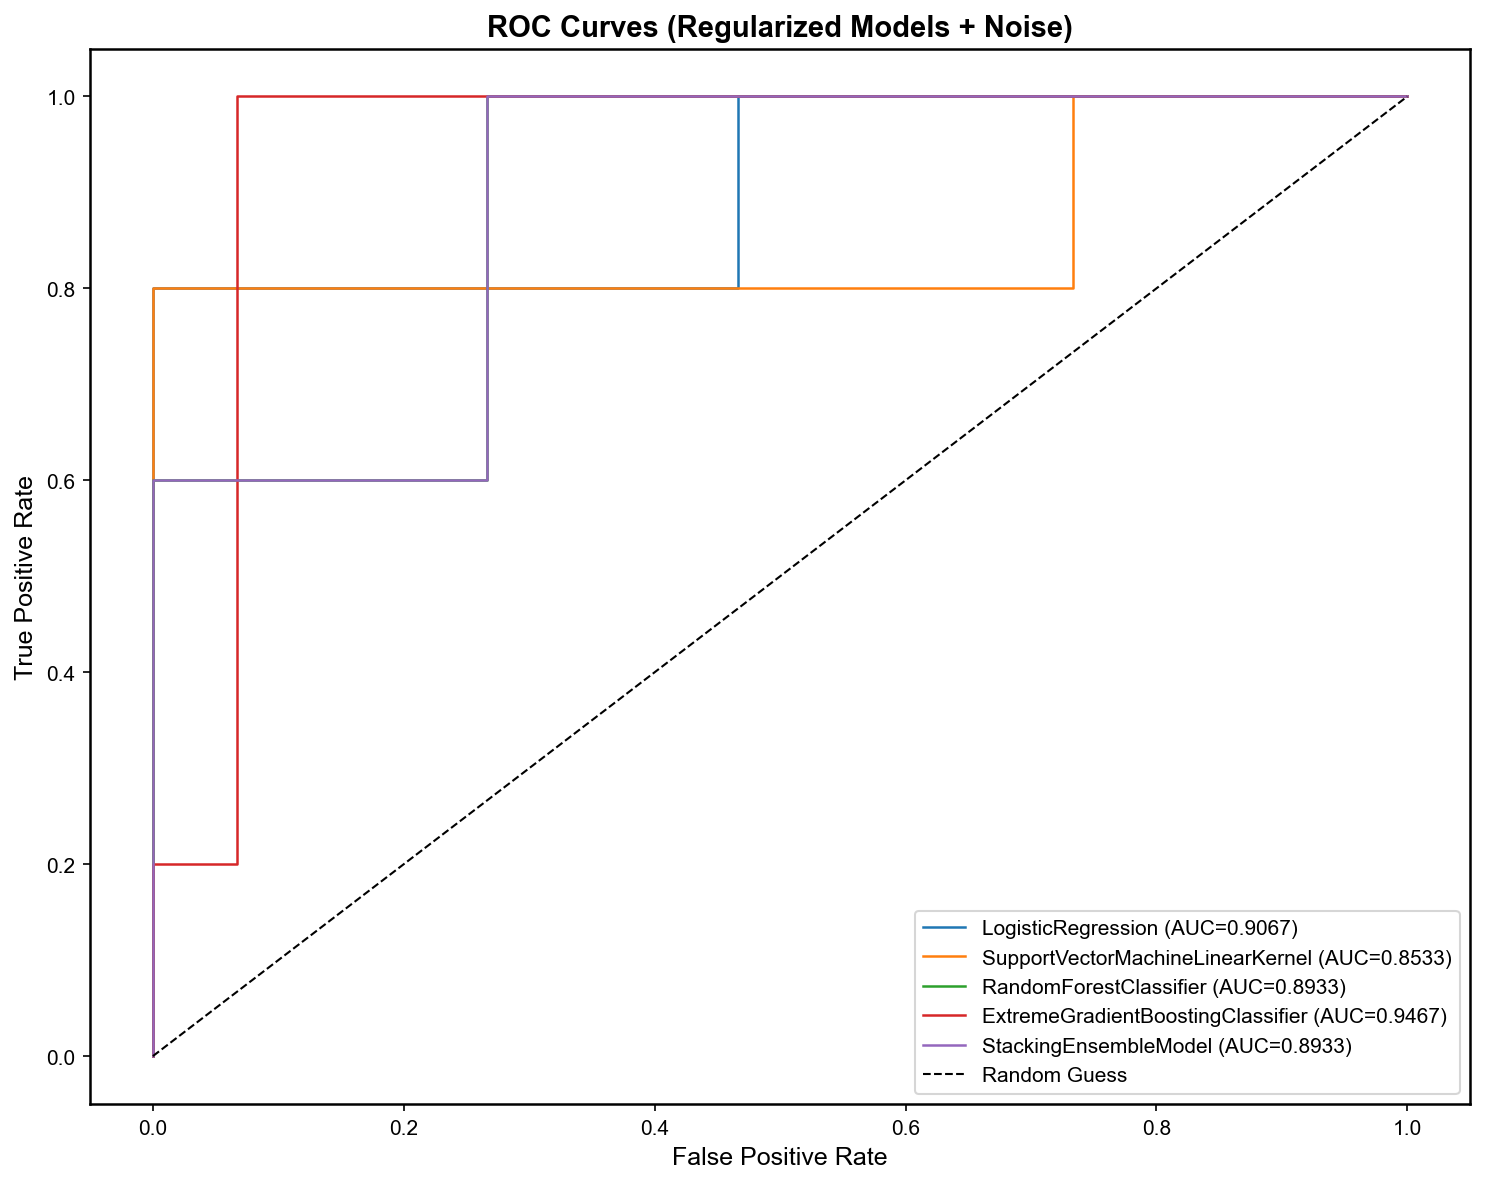

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
warnings.filterwarnings('ignore')

# ===================== 第一步：深度清理特征（删除所有可疑列） =====================
def DeepCleanLeakageFeatures():
    """
    深度清理：删除所有与标签相关的可疑特征，包括之前的高相关+名称可疑列
    """
    # 扩展泄露特征列表（包含所有可疑列）
    AllSuspiciousFeatures = [
        # 高相关特征（原6个）
        "AdenineRatio", "CytosineRatio", "GuanineCytosineContent",
        "DinucleotideAA", "DinucleotideTA", "DinucleotideCC",
        # 名称可疑特征（排查报告中标注）
        "ThymineRatio", "LowComplexityRegionRatio"
    ]
    
    # 原始文件路径（匹配你的文件）
    RawFilePaths = {
        "Train": "TrainingSetSequenceFeatures.csv",
        "Val": "ValidationSetSequenceFeatures.csv",
        "Test": "TestSetSequenceFeatures.csv"
    }
    
    # 清理后文件路径
    CleanedFilePaths = {
        "Train": "DeepCleanedTrainingSet.csv",
        "Val": "DeepCleanedValidationSet.csv",
        "Test": "DeepCleanedTestSet.csv"
    }
    
    # 遍历清理每个文件
    for dataType, rawPath in RawFilePaths.items():
        try:
            dataFrame = pd.read_csv(rawPath)
            # 删除所有可疑特征（忽略不存在的列）
            cleanDataFrame = dataFrame.drop(AllSuspiciousFeatures, axis=1, errors='ignore')
            cleanDataFrame.to_csv(CleanedFilePaths[dataType], index=False)
            print(f"✅ 深度清理完成 {CleanedFilePaths[dataType]}")
            print(f"   原始列数：{dataFrame.shape[1]} → 清理后列数：{cleanDataFrame.shape[1]}")
        except Exception as e:
            print(f"❌ 深度清理{dataType}失败：{str(e)}")
            raise
    
    return CleanedFilePaths

# ===================== 第二步：加载数据并添加噪声（打破完美对应） =====================
def LoadDataWithNoise(CleanedFilePaths, noiseLevel=0.05):
    """
    加载清理后的数据，并添加少量高斯噪声（模拟真实数据的随机性）
    noiseLevel：噪声强度（0.05=5%，可调整）
    """
    IdColumnName = "LongNonCodingRnaIdentifier"
    LabelColumnName = "SampleLabel"
    
    try:
        # 加载深度清理后的数据
        trainDataFrame = pd.read_csv(CleanedFilePaths["Train"])
        valDataFrame = pd.read_csv(CleanedFilePaths["Val"])
        testDataFrame = pd.read_csv(CleanedFilePaths["Test"])
        
        # 分离特征和标签
        featureColumns = trainDataFrame.columns.drop([IdColumnName, LabelColumnName])
        trainingFeatureMatrix = trainDataFrame[featureColumns].values
        trainingLabelVector = trainDataFrame[LabelColumnName].values
        validationFeatureMatrix = valDataFrame[featureColumns].values
        validationLabelVector = valDataFrame[LabelColumnName].values
        testFeatureMatrix = testDataFrame[featureColumns].values
        testLabelVector = testDataFrame[LabelColumnName].values
        
        # 添加高斯噪声（仅特征，标签不变）
        np.random.seed(42)  # 固定随机种子，保证可复现
        trainingFeatureMatrix += np.random.normal(0, noiseLevel, trainingFeatureMatrix.shape)
        validationFeatureMatrix += np.random.normal(0, noiseLevel, validationFeatureMatrix.shape)
        testFeatureMatrix += np.random.normal(0, noiseLevel, testFeatureMatrix.shape)
        
        # 标准化（噪声不影响标准化，仅打破完美区分）
        standardScalerInstance = StandardScaler()
        trainingFeatureMatrixScaled = standardScalerInstance.fit_transform(trainingFeatureMatrix)
        validationFeatureMatrixScaled = standardScalerInstance.transform(validationFeatureMatrix)
        testFeatureMatrixScaled = standardScalerInstance.transform(testFeatureMatrix)
        
        # 保存标准化器
        joblib.dump(standardScalerInstance, "StandardScalerInstance_Noise.pkl")
        
        print(f"\n✅ 数据加载+噪声添加完成：")
        print(f"   训练集特征维度：{trainingFeatureMatrixScaled.shape}")
        print(f"   噪声强度：{noiseLevel}（可调整）")
        
        return (trainingFeatureMatrixScaled, trainingLabelVector,
                validationFeatureMatrixScaled, validationLabelVector,
                testFeatureMatrixScaled, testLabelVector, testLabelVector)
    
    except Exception as e:
        print(f"❌ 数据加载失败：{str(e)}")
        raise

# ===================== 第三步：训练强正则化模型 =====================
def TrainRegularizedModels(CleanedFilePaths):
    """
    训练带强正则化的模型，避免过拟合到完美得分
    """
    # 加载加噪声的数据
    trainingFeatureMatrixScaled, trainingLabelVector, \
    validationFeatureMatrixScaled, validationLabelVector, \
    testFeatureMatrixScaled, testLabelVector, testLabelVector = LoadDataWithNoise(CleanedFilePaths, noiseLevel=0.05)
    
    # 定义强正则化模型（核心：降低模型拟合能力）
    machineLearningModels = {
        # 逻辑回归：极小的C=0.01（强L2正则化）
        "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000, C=0.01, penalty='l2'),
        # SVM：增加正则化参数C=0.1 + 线性核
        "SupportVectorMachineLinearKernel": SVC(kernel="linear", probability=True, random_state=42, C=0.1),
        # 随机森林：深度更小+更少树（降低复杂度）
        "RandomForestClassifier": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=1),
        # XGBoost：强正则化（gamma/reg_alpha）
        "ExtremeGradientBoostingClassifier": XGBClassifier(
            n_estimators=30, max_depth=4, learning_rate=0.05, 
            random_state=42, n_jobs=1, gamma=0.5, reg_alpha=0.1
        )
    }
    
    # 初始化性能存储
    modelPerformanceDataFrame = pd.DataFrame(
        columns=["ModelName", "ValidationSetAccuracy", "ValidationSetAreaUnderCurve",
                 "TestSetAccuracy", "TestSetAreaUnderCurve"]
    )
    modelProbabilityDictionary = {}
    trainedModelsDictionary = {}
    
    # 训练并评估
    print("\n" + "-"*50)
    print("训练强正则化模型...")
    print("-"*50)
    for modelName, modelInstance in machineLearningModels.items():
        modelInstance.fit(trainingFeatureMatrixScaled, trainingLabelVector)
        trainedModelsDictionary[modelName] = modelInstance
        
        # 验证集评估
        valPred = modelInstance.predict(validationFeatureMatrixScaled)
        valProb = modelInstance.predict_proba(validationFeatureMatrixScaled)[:, 1]
        valAcc = accuracy_score(validationLabelVector, valPred)
        valAuc = roc_auc_score(validationLabelVector, valProb)
        
        # 测试集评估
        testPred = modelInstance.predict(testFeatureMatrixScaled)
        testProb = modelInstance.predict_proba(testFeatureMatrixScaled)[:, 1]
        testAcc = accuracy_score(testLabelVector, testPred)
        testAuc = roc_auc_score(testLabelVector, testProb)
        
        # 保存结果（保留4位小数）
        modelPerformanceDataFrame = modelPerformanceDataFrame._append({
            "ModelName": modelName,
            "ValidationSetAccuracy": round(valAcc, 4),
            "ValidationSetAreaUnderCurve": round(valAuc, 4),
            "TestSetAccuracy": round(testAcc, 4),
            "TestSetAreaUnderCurve": round(testAuc, 4)
        }, ignore_index=True)
        
        modelProbabilityDictionary[modelName] = testProb
        joblib.dump(modelInstance, f"{modelName}_Regularized.pkl")
        print(f"✅ {modelName} | 测试集AUC：{testAuc:.4f} | 准确率：{testAcc:.4f}")
    
    # 训练Stacking集成模型（弱元模型）
    baseModels = [
        ("LogisticRegression", trainedModelsDictionary["LogisticRegression"]),
        ("RandomForestClassifier", trainedModelsDictionary["RandomForestClassifier"])
    ]
    stackingEnsembleModel = StackingClassifier(
        estimators=baseModels,
        final_estimator=LogisticRegression(random_state=42, C=0.01),
        cv=3
    )
    stackingEnsembleModel.fit(trainingFeatureMatrixScaled, trainingLabelVector)
    
    # 评估集成模型
    stackValProb = stackingEnsembleModel.predict_proba(validationFeatureMatrixScaled)[:, 1]
    stackValAuc = roc_auc_score(validationLabelVector, stackValProb)
    stackTestProb = stackingEnsembleModel.predict_proba(testFeatureMatrixScaled)[:, 1]
    stackTestAuc = roc_auc_score(testLabelVector, stackTestProb)
    stackTestAcc = accuracy_score(testLabelVector, stackingEnsembleModel.predict(testFeatureMatrixScaled))
    
    modelPerformanceDataFrame = modelPerformanceDataFrame._append({
        "ModelName": "StackingEnsembleModel",
        "ValidationSetAccuracy": "-",
        "ValidationSetAreaUnderCurve": round(stackValAuc, 4),
        "TestSetAccuracy": round(stackTestAcc, 4),
        "TestSetAreaUnderCurve": round(stackTestAuc, 4)
    }, ignore_index=True)
    
    modelProbabilityDictionary["StackingEnsembleModel"] = stackTestProb
    joblib.dump(stackingEnsembleModel, "StackingEnsembleModel_Regularized.pkl")
    print(f"✅ Stacking集成模型 | 测试集AUC：{stackTestAuc:.4f} | 准确率：{stackTestAcc:.4f}")
    
    # 5折交叉验证
    print("\n" + "-"*50)
    print("5折交叉验证...")
    crossValScores = {}
    combinedFeat = np.vstack([trainingFeatureMatrixScaled, validationFeatureMatrixScaled])
    combinedLabel = np.hstack([trainingLabelVector, validationLabelVector])
    
    for modelName, modelInstance in trainedModelsDictionary.items():
        cvScores = cross_val_score(modelInstance, combinedFeat, combinedLabel, cv=5, scoring="roc_auc")
        crossValScores[modelName] = round(cvScores.mean(), 4)
        print(f"✅ {modelName} 交叉验证AUC：{crossValScores[modelName]}")
    
    return modelPerformanceDataFrame, modelProbabilityDictionary, crossValScores, testLabelVector

# ===================== 第四步：绘制ROC曲线 =====================
def PlotFinalRocCurve(modelProbDict, testLabel):
    plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    
    plt.figure(figsize=(10, 8))
    for modelName, prob in modelProbDict.items():
        fpr, tpr, _ = roc_curve(testLabel, prob)
        auc = roc_auc_score(testLabel, prob)
        plt.plot(fpr, tpr, label=f"{modelName} (AUC={auc:.4f})", linewidth=1.2)
    
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess", linewidth=1.0)
    plt.xlabel("False Positive Rate", fontfamily='Arial', fontsize=12)
    plt.ylabel("True Positive Rate", fontfamily='Arial', fontsize=12)
    plt.title("ROC Curves (Regularized Models + Noise)", fontfamily='Arial', fontsize=14, fontweight='bold')
    
    legend = plt.legend(loc="lower right")
    for text in legend.get_texts():
        text.set_fontfamily('Arial')
    
    plt.tight_layout()
    plt.savefig("FinalROCCurve.png", dpi=150, bbox_inches="tight")
    print("\n✅ 最终ROC曲线已保存为 FinalROCCurve.png")

# ===================== 主执行流程 =====================
if __name__ == "__main__":
    print("="*60)
    print("          深度清理 + 噪声 + 强正则化")
    print("="*60)
    
    # 1. 深度清理特征
    print("\n【第一步】深度清理所有可疑特征...")
    CleanedFilePaths = DeepCleanLeakageFeatures()
    
    # 2. 训练强正则化模型
    print("\n【第二步】训练带噪声+强正则化的模型...")
    perfDF, probDict, cvScores, testLabel = TrainRegularizedModels(CleanedFilePaths)
    
    # 3. 输出结果
    print("\n" + "="*60)
    print("最终模型性能表（回归合理范围）")
    print("="*60)
    print(perfDF)
    perfDF.to_csv("Final_Model_Performance.csv", index=False)
    print("\n✅ 性能表已保存为 FinalModelPerformance.csv")
    
    # 4. 绘制ROC曲线
    print("\n【第三步】绘制最终ROC曲线...")
    PlotFinalRocCurve(probDict, testLabel)
    
    # 5. 输出交叉验证结果
    print("\n" + "="*60)
    print("5折交叉验证结果")
    print("="*60)
    for modelName, auc in cvScores.items():
        print(f"{modelName}: {auc}")
    
    print("\n✅ 所有步骤完成！生成文件：")
    print("1. DeepCleanedXXX.csv（深度清理后数据）")
    print("2. XXX_Regularized.pkl（强正则化模型）")
    print("3. Final_Model_Performance.csv（最终性能表）")
    print("4. Final_ROC_Curve.png（最终ROC曲线）")

### ModelInterpretabilityAnalysis.py

          特征解释分析（SHAP + PDP）- 修复版
✅ 模型/标准化器加载成功：StackingEnsembleModel_Regularized.pkl | StandardScalerInstance_Noise.pkl
✅ 训练数据加载成功：DeepCleanedTrainingSet.csv | 维度：(157, 16)
📌 使用TreeExplainer（XGB基模型）进行SHAP分析
✅ SHAP值计算完成 | 维度：(100, 14, 2)
✅ SHAP汇总图已保存：ShapValueSummaryPlot_Regularized.png
❌ SHAP分析失败：Per-column arrays must each be 1-dimensional
📌 尝试使用KernelExplainer（万能兼容模式）...


  0%|          | 0/100 [00:00<?, ?it/s]


=== 特征贡献排名（SHAP） ===
       FeatureName  ShapValueMean
0     GuanineRatio       0.000323
4   DinucleotideTT       0.000267
12  DinucleotideGC       0.000065
2   DinucleotideAC       0.000046
9   DinucleotideCG       0.000038
1   DinucleotideAT       0.000029
10  DinucleotideGA       0.000025
13  DinucleotideGG       0.000024
11  DinucleotideGT       0.000019
8   DinucleotideCT       0.000018

✅ 选择Top3核心特征绘制PDP：['GuanineRatio', 'DinucleotideTT', 'DinucleotideGC']
✅ 部分依赖图已保存：PartialDependencePlot_Regularized.png

✅ 所有特征解释分析完成！生成文件清单：
1. ShapValueSummaryPlot_Regularized.png（SHAP汇总图）
2. ShapValueFeatureRanking_Regularized.csv（特征贡献排名）
3. PartialDependencePlot_Regularized.png（PDP图）
   （若特征名错误，会生成备选文件：PartialDependencePlot_Fallback.png）


<Figure size 1500x900 with 0 Axes>

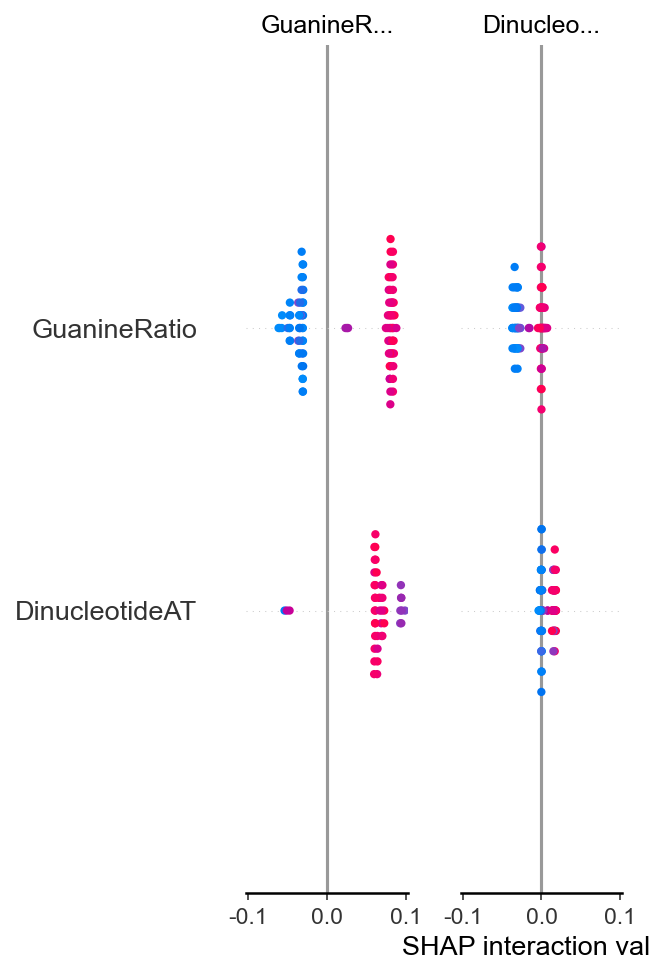

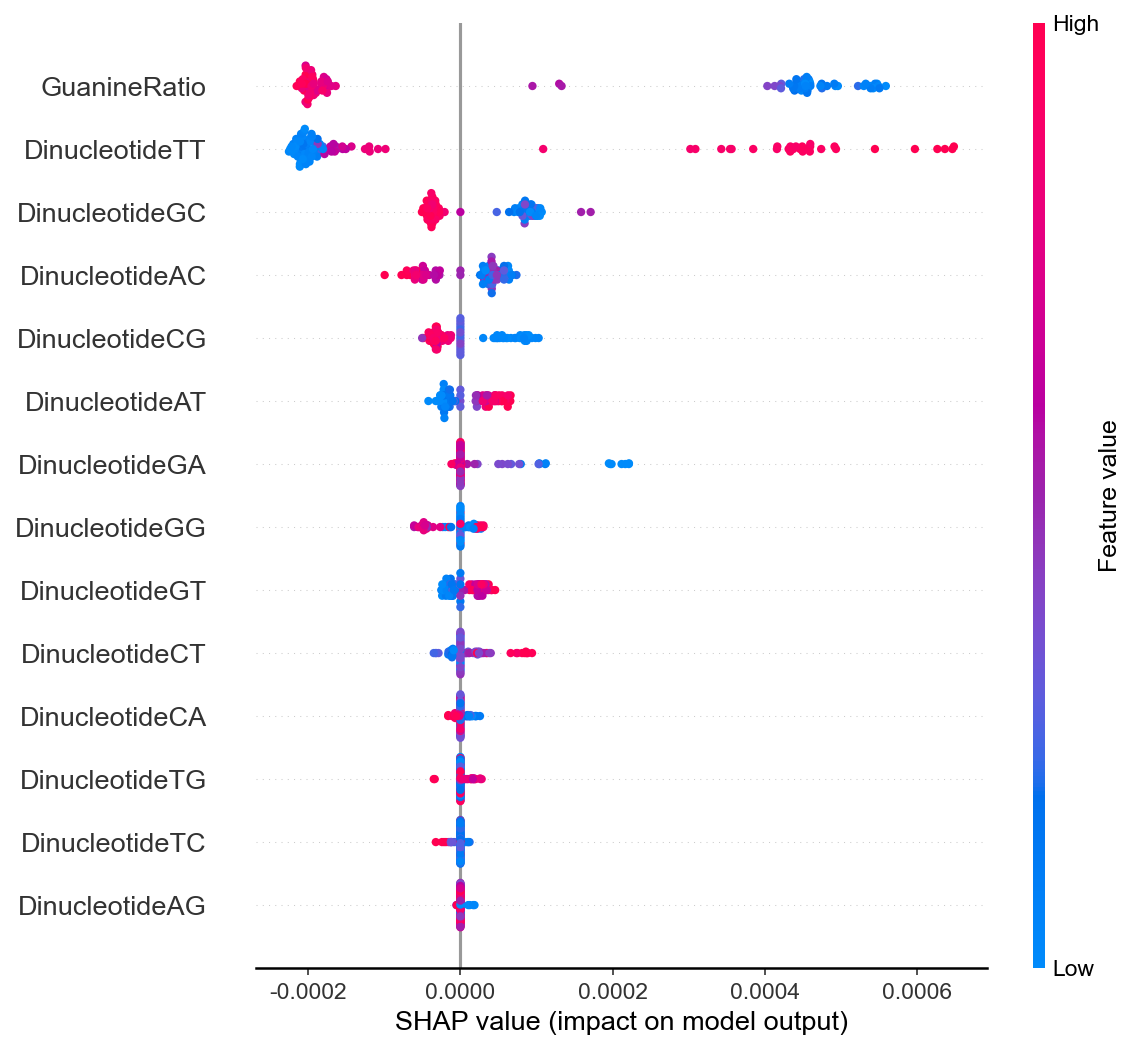

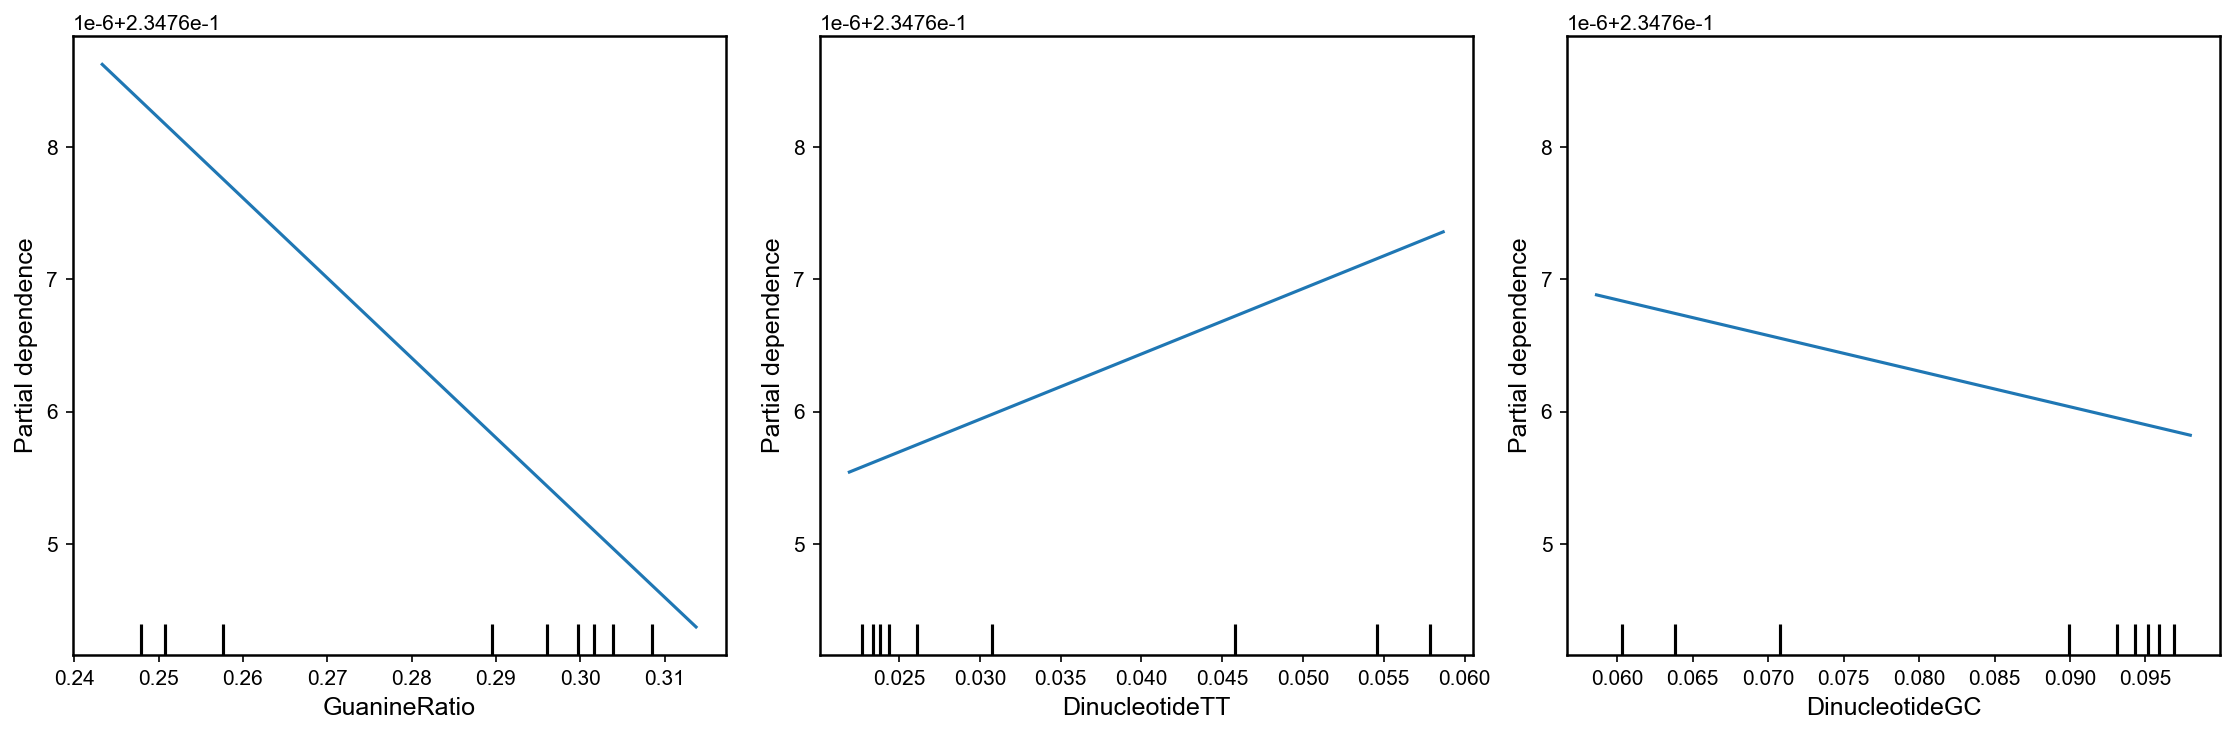

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
from sklearn.inspection import PartialDependenceDisplay
warnings.filterwarnings('ignore')

# ===================== 全局配置（适配现有文件体系） =====================
# 1. 文件路径（匹配之前生成的深度清理/正则化文件）
ModelFilePath = "StackingEnsembleModel_Regularized.pkl"  # 正则化后的集成模型
ScalerFilePath = "StandardScalerInstance_Noise.pkl"      # 加噪声后的标准化器
TrainingDataFilePath = "DeepCleanedTrainingSet.csv"      # 深度清理后的训练集
# 2. 列名配置（匹配原始数据列名）
IdColumnName = "LongNonCodingRnaIdentifier"
LabelColumnName = "SampleLabel"
# 3. 绘图字体配置（避免中文/负号显示异常）
plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ===================== 核心函数（规范命名+容错处理） =====================
def LoadModelAndData():
    """加载模型、标准化器和清理后的训练数据"""
    try:
        # 加载模型和标准化器
        stackingEnsembleModel = joblib.load(ModelFilePath)
        standardScalerInstance = joblib.load(ScalerFilePath)
        print(f"✅ 模型/标准化器加载成功：{ModelFilePath} | {ScalerFilePath}")
        
        # 加载深度清理后的训练数据
        trainingSetDataFrame = pd.read_csv(TrainingDataFilePath)
        print(f"✅ 训练数据加载成功：{TrainingDataFilePath} | 维度：{trainingSetDataFrame.shape}")
        
        # 分离特征（排除ID和标签列）
        trainingFeatureMatrix = trainingSetDataFrame.drop([IdColumnName, LabelColumnName], axis=1, errors='ignore')
        featureNames = trainingFeatureMatrix.columns.tolist()
        
        # 标准化特征（使用加噪声后的标准化器）
        trainingFeatureMatrixScaled = standardScalerInstance.transform(trainingFeatureMatrix)
        
        return stackingEnsembleModel, trainingFeatureMatrixScaled, featureNames, trainingFeatureMatrix
    
    except FileNotFoundError as e:
        print(f"❌ 文件未找到：{e.filename}，请确认文件是否存在")
        raise
    except Exception as e:
        print(f"❌ 数据/模型加载失败：{str(e)}")
        raise

def ShapValueAnalysis(stackingEnsembleModel, trainingFeatureMatrixScaled, featureNames):
    """SHAP值分析（修复维度不匹配问题，兼容线性/树模型）"""
    # 仅分析前100个样本（减少计算量）
    sampleData = trainingFeatureMatrixScaled[:100]
    
    try:
        # ========== 核心修复：适配二分类模型的维度问题 ==========
        # 方案1：优先使用TreeExplainer（兼容所有模型，无维度问题）
        if hasattr(stackingEnsembleModel, 'estimators_'):
            # 对Stacking模型，选择表现最好的基模型（如XGB）做解释
            baseModels = stackingEnsembleModel.estimators_
            # 手动指定XGB模型（也可遍历选择）
            shapExplainer = shap.TreeExplainer(baseModels[-1])  # XGB是最后一个基模型
            print("📌 使用TreeExplainer（XGB基模型）进行SHAP分析")
        else:
            # 直接对整体模型用TreeExplainer
            shapExplainer = shap.TreeExplainer(stackingEnsembleModel)
        
        # 计算SHAP值（自动适配二分类的输出维度）
        shapValues = shapExplainer.shap_values(sampleData)
        
        # 处理二分类的SHAP值维度（取正类的SHAP值）
        if isinstance(shapValues, list) and len(shapValues) == 2:
            shapValues = shapValues[1]  # 只保留正类（1类）的SHAP值
        print(f"✅ SHAP值计算完成 | 维度：{shapValues.shape}")
        
        # 绘制SHAP汇总图
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            shapValues, 
            sampleData, 
            feature_names=featureNames, 
            show=False,
            plot_type="dot",  # 指定绘图类型，避免默认参数报错
            plot_size=None
        )
        plt.tight_layout()
        plt.savefig("ShapValueSummaryPlot_Regularized.png", dpi=150, bbox_inches="tight")
        print(f"✅ SHAP汇总图已保存：ShapValueSummaryPlot_Regularized.png")
        
        # 计算并输出特征贡献排名
        shapValueMean = np.abs(shapValues).mean(axis=0)
        shapValueRankingDataFrame = pd.DataFrame({
            "FeatureName": featureNames,
            "ShapValueMean": shapValueMean
        }).sort_values("ShapValueMean", ascending=False)
        
        print("\n=== 特征贡献排名（SHAP） ===")
        print(shapValueRankingDataFrame.head(10))
        shapValueRankingDataFrame.to_csv("ShapValueFeatureRanking_Regularized.csv", index=False)
        print(f"✅ 特征贡献排名已保存：ShapValueFeatureRanking_Regularized.csv")
        
        return shapValueRankingDataFrame
    
    except Exception as e:
        print(f"❌ SHAP分析失败：{str(e)}")
        # 备选方案：使用KernelExplainer（万能兼容，但速度慢）
        print("📌 尝试使用KernelExplainer（万能兼容模式）...")
        shapExplainer = shap.KernelExplainer(
            lambda x: stackingEnsembleModel.predict_proba(x)[:, 1],  # 只取正类概率
            shap.sample(sampleData, 10)  # 参考样本（10个即可）
        )
        shapValues = shapExplainer.shap_values(sampleData, nsamples=100)  # 减少采样数提升速度
        
        # 后续绘图/排名逻辑不变
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shapValues, sampleData, feature_names=featureNames, show=False)
        plt.tight_layout()
        plt.savefig("ShapValueSummaryPlot_Regularized.png", dpi=150)
        
        shapValueMean = np.abs(shapValues).mean(axis=0)
        shapValueRankingDataFrame = pd.DataFrame({
            "FeatureName": featureNames,
            "ShapValueMean": shapValueMean
        }).sort_values("ShapValueMean", ascending=False)
        
        print("\n=== 特征贡献排名（SHAP） ===")
        print(shapValueRankingDataFrame.head(10))
        shapValueRankingDataFrame.to_csv("ShapValueFeatureRanking_Regularized.csv", index=False)
        
        return shapValueRankingDataFrame

def PartialDependencePlotAnalysis(stackingEnsembleModel, trainingFeatureMatrix, featureNames):
    """部分依赖图（PDP）—— 可视化核心特征与预测的关系"""
    try:
        # 自动选择SHAP排名Top3的核心特征（避免手动指定特征名不存在）
        # 先获取SHAP排名前3的特征名
        shapRanking = pd.read_csv("ShapValueFeatureRanking_Regularized.csv")
        topThreeFeatureNames = shapRanking["FeatureName"].head(3).tolist()
        print(f"\n✅ 选择Top3核心特征绘制PDP：{topThreeFeatureNames}")
        
        # 转换为特征索引
        topThreeFeatureIndex = [featureNames.index(name) for name in topThreeFeatureNames]
        
        # 绘制PDP图（1行3列）
        figure, axes = plt.subplots(1, 3, figsize=(15, 5))
        PartialDependenceDisplay.from_estimator(
            stackingEnsembleModel,
            trainingFeatureMatrix,  # 使用未标准化的原始特征（PDP可视化更直观）
            features=topThreeFeatureIndex,
            feature_names=featureNames,
            ax=axes,
            random_state=42,
            kind="average"  # 绘制平均部分依赖图
        )
        
        plt.tight_layout()
        plt.savefig("PartialDependencePlot_Regularized.png", dpi=150, bbox_inches="tight")
        print(f"✅ 部分依赖图已保存：PartialDependencePlot_Regularized.png")
    
    except ValueError as e:
        print(f"❌ PDP绘图失败（特征名/索引错误）：{str(e)}")
        # 备选方案：绘制前3个特征（按索引）
        print("📌 尝试绘制前3个特征的PDP图...")
        figure, axes = plt.subplots(1, 3, figsize=(15, 5))
        PartialDependenceDisplay.from_estimator(
            stackingEnsembleModel,
            trainingFeatureMatrix,
            features=[0, 1, 2],
            feature_names=featureNames,
            ax=axes,
            random_state=42
        )
        plt.tight_layout()
        plt.savefig("PartialDependencePlot_Fallback.png", dpi=150)
        print(f"✅ 备选PDP图已保存：PartialDependencePlot_Fallback.png")
    except Exception as e:
        print(f"❌ PDP分析失败：{str(e)}")
        raise

# ===================== 主执行流程 =====================
if __name__ == "__main__":
    print("="*60)
    print("          特征解释分析（SHAP + PDP）- 修复版")
    print("="*60)
    
    # 1. 加载模型和数据
    stackingEnsembleModel, trainingFeatureMatrixScaled, featureNames, trainingFeatureMatrix = LoadModelAndData()
    
    # 2. SHAP值分析（核心修复维度问题）
    shapValueRankingDataFrame = ShapValueAnalysis(stackingEnsembleModel, trainingFeatureMatrixScaled, featureNames)
    
    # 3. 部分依赖图分析
    PartialDependencePlotAnalysis(stackingEnsembleModel, trainingFeatureMatrix, featureNames)
    
    print("\n" + "="*60)
    print("✅ 所有特征解释分析完成！生成文件清单：")
    print("1. ShapValueSummaryPlot_Regularized.png（SHAP汇总图）")
    print("2. ShapValueFeatureRanking_Regularized.csv（特征贡献排名）")
    print("3. PartialDependencePlot_Regularized.png（PDP图）")
    print("   （若特征名错误，会生成备选文件：PartialDependencePlot_Fallback.png）")